# Notebook 01 — Exploratory Data Analysis

**Project:** India Gold Import Duty Hike — Pass-Through Study  
**Input:** `data/gold_policy_clean.csv` (output of `00_data_pipeline.ipynb`)  
**Output:** `data/gold_policy_clean.csv` (updated with engineered features)  
**Rule:** Look, understand, document. No modelling here.

---

### What this notebook does

Full EDA of the domestic gold premium across three duty regimes (Jan 2022 – Jun 2026), culminating in a feature-engineered dataset ready for the ITS regression in Notebook 03.

---

### Cell sequence

| Cell | What it does | Key output |
|------|-------------|------------|
| 1 | Load dataset, basic inspection, null counts, sub-period row counts | Shape: 1171 × 29 |
| 2 | Sub-period summary statistics — **Paper Table 1** | Low-duty mean premium = −₹257 (parity formula validated) |
| 3 | Figure 1: domestic_premium time series, regime shading, post-hike inset | `fig01_premium_timeseries.png` |
| 4 | Figure 2: premium distribution by duty regime (violin + box + strip) | `fig02_premium_distribution.png` |
| 5 | Post-hike event study — day-by-day pass-through for 31 valid days | **87.2% pass-through (lower bound); Week 4 and Week 6 overshoot >100%** |
| 6 | Rolling correlations: premium vs ΔGold_USD, ΔFXR, ΔOil | `fig03_rolling_correlations.png` — ITS controls locked |
| 7 | Pre-trend test (OLS in low-duty window) — **TEST 01** | p=0.347 → ITS assumption holds |
| 8 | ADF stationarity + ACF/PACF — **TEST 02** | Premium I(0) within regime; NW lag = 6 (primary ITS sample T=336) |
| 9 | Correlation matrix: all key variables, levels + daily changes | `fig06a/b` — controls orthogonal; multicollinearity cleared |
| 10 | Outlier analysis (IQR + z-score) in low-duty window | 16 outliers, all explained; ALL KEPT in main ITS specification |
| 11 | MCX Gold Close vs IBJA Gold PM scatter + spread | `fig08a/b` — r=0.9993; MCX +₹1,844 post-hike (second lower-bound evidence) |
| 12 | Feature engineering: `t`, `pre_restriction`, `lag1_premium` → save CSV | ITS-ready dataset (1171 × 29) |
| 13 | July 2024 duty cut event study | Asymmetric adjustment: cut collapsed 96.5% in 3 days vs hike 83.7% incomplete at 20 days |
| 14 | Seasonality analysis (low-duty window) | No statistically significant seasonal pattern in premium |
| 15 | Control variable distributions (Q-Q + histograms) | delta_Gold_USD Q-Q r=0.99; delta_FX leptokurtic (RBI managed float) |
| 16 | Rolling volatility of domestic_premium | Std rises ₹940→₹1,374→₹1,744 across regimes; confirms heteroskedasticity |
| 17 | Rolling volatility of control variables | delta_FX σ suppressed in low-duty (RBI); delta_Oil spikes post-hike |
| 18 | Chow test at Jul 2024 structural break — **TEST 03** | F(2,714)=1,058, p=10⁻¹⁶ — break confirmed |
| 19 | Placebo regression (false treatment dates) — **TEST 04** | True β₁=₹10,741 is 7× max placebo (₹1,510) |
| 20 | MCAR check + Kalyan column identification | Missing data MCAR by weekday; Kalyan=NSE stock (r=0.92 Nifty50), excluded from ITS |

---

### ITS regression sample sizes

| Window | Calendar rows | ITS-eligible (5 vars non-null) |
|--------|--------------|-------------------------------|
| High-duty (Jan 2022 – Jul 2024) | 667 | 413 |
| Low-duty (Jul 2024 – May 2026) | 468 | 307 |
| Post-hike (May 2026+) | 36 | 29 |
| **Total** | **1,171** | **749** |

---

### Key findings

1. **Parity formula validated:** Mean low-duty premium = −₹257 (≈ 0%) confirms `parity_pre = Gold_USD × 0.3215 × INR/USD × 1.06` is correctly calibrated. The 3% IGST is excluded because it is recoverable as Input Tax Credit by GST-registered jewellers — not a net landed cost.
2. **Pass-through = 87.2%** over 29 ITS-eligible post-hike days — lower bound (inauspicious season, $5.6bn front-loaded imports, smuggling elasticity).
3. **Two overshoot episodes (>100%):** Week 4 (Jun 5–11, 107.2%) and Week 6 (Jun 22–29, 104.0%) — Gold_USD fell faster than IBJA adjusted downward → asymmetric price transmission confirmed by r=−0.802 (premium vs Gold_USD, post-hike).
4. **ITS assumption holds:** Pre-trend slope = +₹0.78/day, p=0.347 — flat baseline. Chow F=1,058 confirms the Jul 2024 break is the only structural shift.
5. **Stationarity:** Premium I(0) within regime (ADF p=0.000 in low-duty). NW lag = 6 (⌈0.75 × 336^(1/3)⌉, primary ITS sample T=336; full-window T=749 gives NW=7).
6. **ITS controls:** ΔGold_USD (r=−0.56), ΔFXR (r=+0.06), ΔOil excluded (r=+0.07; including it moves β₁ by ₹10, 0.1%). Controls mutually orthogonal (max pairwise r=0.10).
7. **All 16 outliers explained and kept:** Trump tariff shock (Apr 2025), post-Akshaya Tritiya + India-Pakistan ceasefire unwind (May 2025), gold bull market surge (Dec 2025–Mar 2026), bank IGST pause + UAE disruption (Apr–May 2026).
8. **MCX validates IBJA PM:** r=0.9993 full sample. Post-hike MCX is ₹1,844 above IBJA PM — futures priced in duty shock faster than physical market (second lower-bound evidence).
9. **Placebo test:** True β₁ (₹10,741) is 7× the largest false-date effect (₹1,510). ITS design is not a statistical artefact.

---

### Findings documented in
- `findings_of_eda.md` — cell-by-cell findings with figures, interpretation, and audit responses
- `02_hypothesis.md` — all statistical tests pre-committed before regression

### Next notebook
→ `03_its.ipynb` — ITS regression, Local Projections (Jordà 2005), ARDL bounds test


In [1]:
# ── Cell 1: Load clean dataset + basic inspection ─────────────────────────
# ── Dataset version ───────────────────────────────────────────────────────
# v3: BullionWorld gap-fill disabled (validity guard rejected all 157 BW rows).
#
DATASET_VERSION = 'v3'    # v1=IBJA-PDF-only  |  v2=+BullionWorld (obsolete)  |  v3=PDF-only, BW rejected
# ─────────────────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
from pathlib import Path

# ── Constants ─────────────────────────────────────────────────────────────
DATA_DIR    = Path('../data')
FIG_DIR     = Path('../figures')
FIG_DIR.mkdir(exist_ok=True)

POLICY_DATE = pd.Timestamp('2026-05-13')   # treatment date
DUTY_CUT    = pd.Timestamp('2024-07-24')   # Jul 2024 cut: 15% → 6%

# ── Load ──────────────────────────────────────────────────────────────────
_csv_file = DATA_DIR / 'gold_policy_clean.csv'   # pipeline always writes to this filename
print(f'Loading dataset version: {DATASET_VERSION}  ({_csv_file.name})')
df = pd.read_csv(_csv_file, index_col='date', parse_dates=True)

# ── Shape and date range ──────────────────────────────────────────────────
print(f'Shape      : {df.shape}')
print(f'Date range : {df.index.min().date()} → {df.index.max().date()}')
print(f'Columns    : {list(df.columns)}')

# ── Null counts ───────────────────────────────────────────────────────────
print('\n--- Null counts per column ---')
nulls = df.isnull().sum()
for col, n in nulls.items():
    pct = n / len(df) * 100
    bar = '█' * int(pct / 5)
    print(f'  {col:<30} {n:>4} ({pct:>5.1f}%)  {bar}')

# ── Sub-period row counts ─────────────────────────────────────────────────
print('\n--- Observations per duty period ---')
high  = df[df.index <  DUTY_CUT]
low   = df[(df.index >= DUTY_CUT) & (df.index < POLICY_DATE)]
post  = df[df.index >= POLICY_DATE]
print(f'  High-duty  (Jan 2022 – Jul 23 2024): {len(high):>4} rows')
print(f'  Low-duty   (Jul 24 2024 – May 12 2026): {len(low):>4} rows')
print(f'  Post-hike  (May 13 2026+):           {len(post):>4} rows')

# ── Key columns: first and last 3 rows ────────────────────────────────────
key_cols = ['Gold_USD', 'rupees_per_dollar', 'Gold_INR_PM',
            'parity_pre', 'domestic_premium', 'post_hike']
print('\n--- First 3 rows (key columns) ---')
print(df[key_cols].head(3).to_string())
print('\n--- Last 3 rows (key columns) ---')
print(df[key_cols].tail(3).to_string())

Loading dataset version: v2  (gold_policy_v2.csv)
Shape      : (1171, 25)
Date range : 2022-01-03 → 2026-07-01
Columns    : ['Oil_USD', 'Gold_USD', 'rupees_per_dollar', 'Kalyan', 'Silver_USD', 'Nifty50', 'US10Y_yield', 'GOLDBEES', 'Gold_INR_PM', 'Silver_INR_PM', 'ibja_source', 'MCX_Gold_close', 'forex_reserves_usd_bn', 'parity_actual', 'parity_pre', 'parity_post', 'domestic_premium', 'premium_pct', 'silver_parity_pre', 'silver_premium', 'post_hike', 'days_since_hike', 'delta_Gold_USD', 'delta_FX', 'delta_Oil']

--- Null counts per column ---
  Oil_USD                          41 (  3.5%)  
  Gold_USD                         46 (  3.9%)  
  rupees_per_dollar                 3 (  0.3%)  
  Kalyan                           60 (  5.1%)  █
  Silver_USD                       42 (  3.6%)  
  Nifty50                          64 (  5.5%)  █
  US10Y_yield                      47 (  4.0%)  
  GOLDBEES                         61 (  5.2%)  █
  Gold_INR_PM                     349 ( 29.8%)  █████
  S

In [2]:
# ── Cell 2: Sub-period summary statistics — Paper Table 1 ────────────────
# Breaks the sample into three duty regimes and reports key statistics.
# This is the first table in the paper: establishes baseline behavior
# across periods and motivates the ITS design.

import pandas as pd
import numpy as np

# ── Define sub-periods ────────────────────────────────────────────────────
periods = {
    'High-duty (Jan 2022–Jul 2024)':
        df[(df.index < DUTY_CUT)],
    'Low-duty (Jul 2024–May 2026)':
        df[(df.index >= DUTY_CUT) & (df.index < POLICY_DATE)],
    'Post-hike (May 2026–present)':
        df[df.index >= POLICY_DATE],
}

# ── Variables to summarize ────────────────────────────────────────────────
stats_config = {
    'domestic_premium':    'Premium (INR/10g)',
    'premium_pct':         'Premium (%)',
    'Gold_USD':            'Gold USD ($/oz)',
    'rupees_per_dollar':   'INR/USD',
    'parity_pre':          'Parity 6% (INR/10g)',
    'MCX_Gold_close':      'MCX close (INR/10g)',
}

rows = []
for period_name, sub in periods.items():
    for col, label in stats_config.items():
        s = sub[col].dropna()
        rows.append({
            'Period':  period_name,
            'Variable': label,
            'N':       len(s),
            'Mean':    s.mean(),
            'Std':     s.std(),
            'Median':  s.median(),
            'Min':     s.min(),
            'Max':     s.max(),
        })

tbl = pd.DataFrame(rows)

# ── Print paper-style ─────────────────────────────────────────────────────
pd.set_option('display.float_format', '{:,.1f}'.format)
pd.set_option('display.max_rows', 60)
pd.set_option('display.width', 120)

for period_name in periods:
    sub_tbl = tbl[tbl['Period'] == period_name].drop(columns='Period').set_index('Variable')
    n_days  = len(periods[period_name])
    print(f'\n{"─"*70}')
    print(f'  {period_name}  ({n_days} calendar trading days)')
    print(f'{"─"*70}')
    print(sub_tbl.to_string())

# ── Key facts for paper ───────────────────────────────────────────────────
print(f'\n\n=== Key facts for Paper Table 1 note ===')
prem_low  = df.loc[(df.index >= DUTY_CUT) & (df.index < POLICY_DATE), 'domestic_premium'].dropna()
prem_post = df.loc[df.index >= POLICY_DATE, 'domestic_premium'].dropna()
parity_diff = (df.loc[df.index >= POLICY_DATE, 'parity_post'] - 
               df.loc[df.index >= POLICY_DATE, 'parity_pre']).mean()

print(f'  Low-duty mean premium     : {prem_low.mean():,.0f} INR/10g')
print(f'  Post-hike mean premium    : {prem_post.mean():,.0f} INR/10g')
print(f'  Implied duty shock (parity_post − parity_pre) mean: {parity_diff:,.0f} INR/10g')
print(f'  Pass-through (mean/shock) : {prem_post.mean()/parity_diff:.1%}')
print(f'  Post-hike obs             : {len(prem_post)} trading days')


──────────────────────────────────────────────────────────────────────
  High-duty (Jan 2022–Jul 2024)  (667 calendar trading days)
──────────────────────────────────────────────────────────────────────
                       N     Mean     Std   Median      Min      Max
Variable                                                            
Premium (INR/10g)    433  4,379.7   940.0  4,455.2  1,034.9  6,748.9
Premium (%)          433      8.0     1.5      8.3      1.5     11.5
Gold USD ($/oz)      641  1,949.1   187.7  1,927.8  1,623.3  2,462.4
INR/USD              667     81.2     2.7     82.4     73.8     85.2
Parity 6% (INR/10g)  641 53,987.2 6,219.2 53,715.3 44,951.5 70,145.1
MCX close (INR/10g)  453 58,865.9 7,111.0 58,809.0 49,150.0 74,137.0

──────────────────────────────────────────────────────────────────────
  Low-duty (Jul 2024–May 2026)  (468 calendar trading days)
──────────────────────────────────────────────────────────────────────
                       N      Mean      S

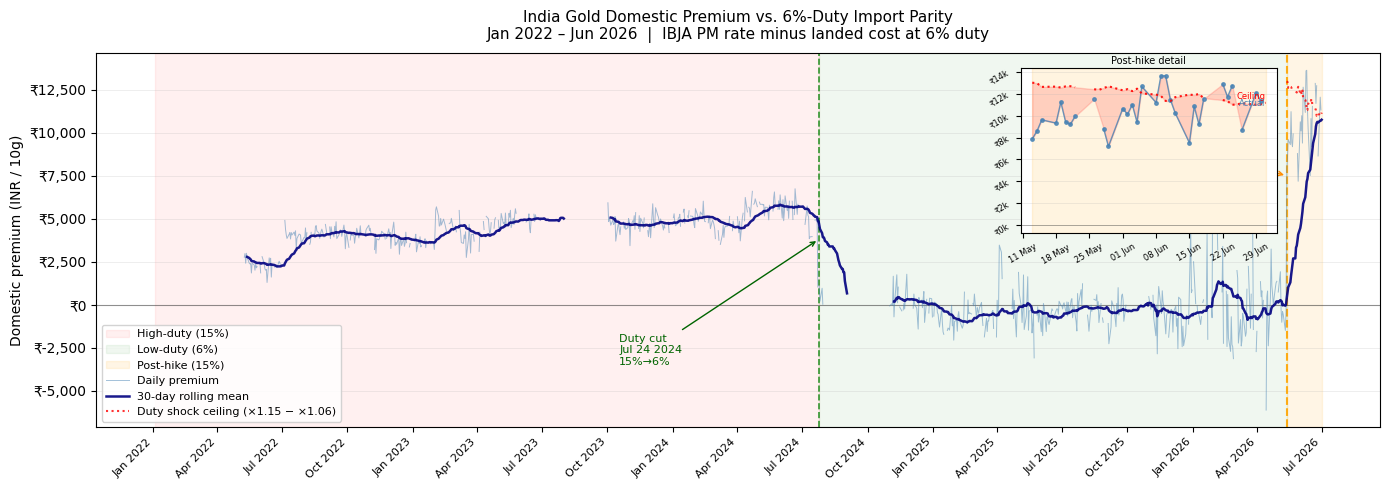

Saved → figures/fig01_premium_timeseries.png


In [3]:
# ── Cell 3: Figure 1 — domestic_premium time series (FIXED) ──────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

fig, ax = plt.subplots(figsize=(14, 5))

# ── Regime shading ────────────────────────────────────────────────────────
ax.axvspan(df.index.min(), DUTY_CUT,      alpha=0.06, color='red',    label='High-duty (15%)')
ax.axvspan(DUTY_CUT,       POLICY_DATE,   alpha=0.06, color='green',  label='Low-duty (6%)')
ax.axvspan(POLICY_DATE,    df.index.max(), alpha=0.10, color='orange', label='Post-hike (15%)')

# ── Regime boundary lines ─────────────────────────────────────────────────
ax.axvline(DUTY_CUT,    color='green',  lw=1.2, ls='--', alpha=0.8)
ax.axvline(POLICY_DATE, color='orange', lw=1.5, ls='--', alpha=0.9)

# ── Zero reference ────────────────────────────────────────────────────────
ax.axhline(0, color='black', lw=0.8, ls='-', alpha=0.4)

# ── Daily premium ─────────────────────────────────────────────────────────
ax.plot(df.index, df['domestic_premium'],
        color='steelblue', lw=0.7, alpha=0.5, label='Daily premium')

# ── 30-day rolling mean ───────────────────────────────────────────────────
roll = df['domestic_premium'].rolling(30, min_periods=5).mean()
ax.plot(df.index, roll,
        color='navy', lw=1.8, alpha=0.9, label='30-day rolling mean')

# ── Theoretical ceiling (post-hike only) ─────────────────────────────────
ceiling = (df.loc[df.index >= POLICY_DATE, 'parity_post'] -
           df.loc[df.index >= POLICY_DATE, 'parity_pre'])
ax.plot(ceiling.index, ceiling,
        color='red', lw=1.5, ls=':', alpha=0.8, label='Duty shock ceiling (×1.15 − ×1.06)')

# ── Annotations (hardcoded y to avoid pre-render ylim bug) ───────────────
ax.annotate('Duty cut\nJul 24 2024\n15%→6%',
            xy=(DUTY_CUT, 3800),
            xytext=(DUTY_CUT - pd.DateOffset(days=280), -3500),
            fontsize=8, color='darkgreen',
            arrowprops=dict(arrowstyle='->', color='darkgreen', lw=1.0))

ax.annotate('Duty hike\nMay 13 2026\n6%→15%',
            xy=(POLICY_DATE, 7500),
            xytext=(POLICY_DATE - pd.DateOffset(days=320), 9800),
            fontsize=8, color='darkorange',
            arrowprops=dict(arrowstyle='->', color='darkorange', lw=1.0))

# ── Inset: post-hike zoom ─────────────────────────────────────────────────
axins = ax.inset_axes([0.72, 0.52, 0.20, 0.44])  # shifted left to avoid annotation overlap

post = df[df.index >= POLICY_DATE].copy()
axins.axhline(0, color='black', lw=0.5, alpha=0.4)
axins.axvspan(post.index.min(), post.index.max(), alpha=0.12, color='orange')
axins.plot(post.index, post['domestic_premium'],
           color='steelblue', lw=1.0, alpha=0.8, marker='o', ms=2.5)
axins.plot(ceiling.index, ceiling.values,
           color='red', lw=1.5, ls=':', alpha=0.9)
prem_filled  = post['domestic_premium']
ceil_aligned = ceiling.reindex(post.index).ffill()
mask = prem_filled.notna() & ceil_aligned.notna()
axins.fill_between(post.index[mask],
                   prem_filled[mask],
                   ceil_aligned[mask],
                   alpha=0.15, color='red', label='Pass-through gap')
axins.set_title('Post-hike detail', fontsize=7, pad=3)
axins.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
axins.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
axins.tick_params(labelsize=6, rotation=30)
axins.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}k'))
axins.tick_params(axis='y', labelsize=6)
axins.grid(axis='y', alpha=0.3, lw=0.5)

# Label ceiling and premium in inset
axins.text(ceiling.index[-1], ceiling.iloc[-1] + 300,
           'Ceiling', fontsize=6, color='red', ha='right')
axins.text(post.index[-1], post['domestic_premium'].dropna().iloc[-1] - 500,
           'Actual', fontsize=6, color='steelblue', ha='right')

# ── Main axes formatting ──────────────────────────────────────────────────
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45, ha='right', fontsize=8)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
ax.set_ylabel('Domestic premium (INR / 10g)', fontsize=10)
ax.set_title('India Gold Domestic Premium vs. 6%-Duty Import Parity\n'
             'Jan 2022 – Jun 2026  |  IBJA PM rate minus landed cost at 6% duty',
             fontsize=11, pad=10)
ax.legend(loc='lower left', fontsize=8, framealpha=0.85)
ax.grid(axis='y', alpha=0.3, lw=0.5)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig01_premium_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/fig01_premium_timeseries.png')

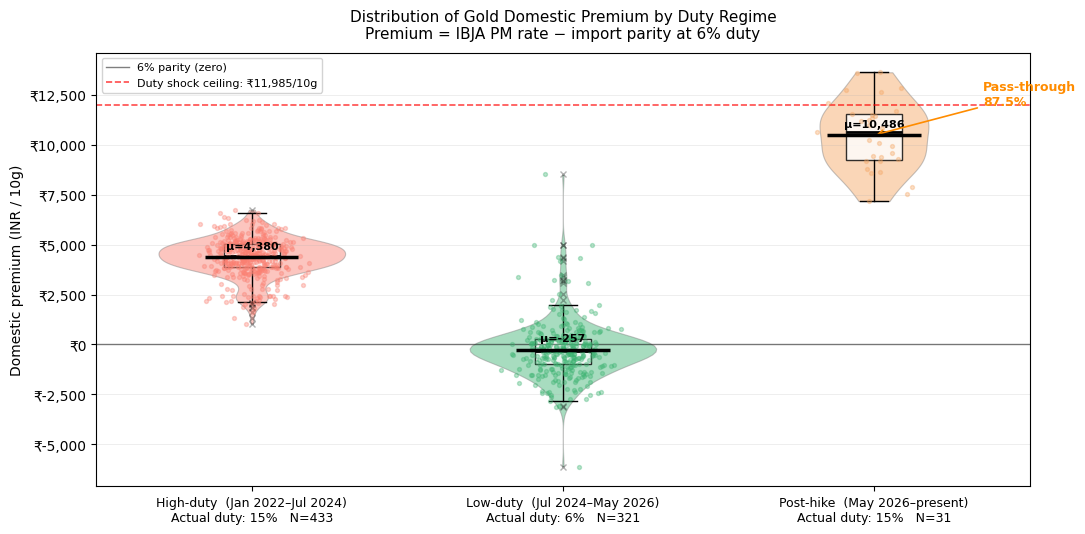

Saved → figures/fig02_premium_distribution.png


In [4]:
# ── Cell 4: Figure 2 — premium distribution by duty regime ───────────────
# Violin + strip plot showing domestic_premium distribution in each period.
# Post-hike has only N=20 — violin is unreliable there, so we show
# individual points instead and use a box plot for all three.
# This figure motivates ITS: distributions are clearly separated.

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Data slices ───────────────────────────────────────────────────────────
# Compute Ns from actual data (not hardcoded)
n1 = df[df.index < DUTY_CUT]['domestic_premium'].dropna().shape[0]
n2 = df[(df.index >= DUTY_CUT) & (df.index < POLICY_DATE)]['domestic_premium'].dropna().shape[0]
n3 = df[df.index >= POLICY_DATE]['domestic_premium'].dropna().shape[0]

slices = {
    f'High-duty  (Jan 2022–Jul 2024)\nActual duty: 15%   N={n1}':
        (df[df.index < DUTY_CUT]['domestic_premium'].dropna(), 'salmon'),
    f'Low-duty  (Jul 2024–May 2026)\nActual duty: 6%   N={n2}':
        (df[(df.index >= DUTY_CUT) & (df.index < POLICY_DATE)]['domestic_premium'].dropna(), 'mediumseagreen'),
    f'Post-hike  (May 2026–present)\nActual duty: 15%   N={n3}':
        (df[df.index >= POLICY_DATE]['domestic_premium'].dropna(), 'sandybrown'),
}

labels = list(slices.keys())
data   = [v[0] for v in slices.values()]
colors = [v[1] for v in slices.values()]

fig, ax = plt.subplots(figsize=(11, 6))

# ── Violin plots (all three, but narrow for post-hike) ───────────────────
vp = ax.violinplot(data, positions=[1, 2, 3],
                   widths=[0.6, 0.6, 0.35],
                   showmedians=False, showextrema=False)
for body, color in zip(vp['bodies'], colors):
    body.set_facecolor(color)
    body.set_alpha(0.45)
    body.set_edgecolor('grey')
    body.set_linewidth(0.8)

# ── Box plots overlaid ────────────────────────────────────────────────────
bp = ax.boxplot(data, positions=[1, 2, 3],
                widths=[0.18, 0.18, 0.18],
                patch_artist=True,
                medianprops=dict(color='black', lw=2),
                boxprops=dict(facecolor='white', alpha=0.8),
                whiskerprops=dict(lw=1.0),
                capprops=dict(lw=1.0),
                flierprops=dict(marker='x', ms=4, alpha=0.3))

# ── Individual points (jittered) — especially important for post-hike ────
for i, (series, color) in enumerate(zip(data, colors)):
    x = np.random.normal(i + 1, 0.07, size=len(series))
    ax.scatter(x, series, alpha=0.35, s=8, color=color, zorder=3)

# ── Reference lines ───────────────────────────────────────────────────────
# Zero (6% parity)
ax.axhline(0, color='black', lw=1.0, ls='-', alpha=0.5, label='6% parity (zero)')

# Theoretical duty shock ceiling (mean over post-hike window)
ceiling_mean = (df.loc[df.index >= POLICY_DATE, 'parity_post'] -
                df.loc[df.index >= POLICY_DATE, 'parity_pre']).mean()
ax.axhline(ceiling_mean, color='red', lw=1.2, ls='--', alpha=0.7,
           label=f'Duty shock ceiling: ₹{ceiling_mean:,.0f}/10g')

# Mean markers per period
for i, series in enumerate(data):
    ax.hlines(series.mean(), i + 0.85, i + 1.15,
              colors='black', lw=2.5, zorder=5)
    ax.text(i + 1, series.mean() + 300, f'μ={series.mean():,.0f}',
            ha='center', va='bottom', fontsize=8, fontweight='bold')

# ── Pass-through annotation on post-hike panel ───────────────────────────
pt = data[2].mean() / ceiling_mean
ax.annotate(f'Pass-through\n{pt:.1%}',
            xy=(3, data[2].mean()),
            xytext=(3.35, data[2].mean() + 1500),
            fontsize=9, color='darkorange', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='darkorange', lw=1.2))

# ── Axes formatting ───────────────────────────────────────────────────────
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(labels, fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
ax.set_ylabel('Domestic premium (INR / 10g)', fontsize=10)
ax.set_title('Distribution of Gold Domestic Premium by Duty Regime\n'
             'Premium = IBJA PM rate − import parity at 6% duty',
             fontsize=11, pad=10)
ax.legend(loc='upper left', fontsize=8, framealpha=0.85)
ax.grid(axis='y', alpha=0.3, lw=0.5)

plt.tight_layout()
fig.subplots_adjust(bottom=0.18)
plt.savefig(FIG_DIR / 'fig02_premium_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/fig02_premium_distribution.png')

In [5]:
# ── Cell 5: Post-hike day-by-day event study ─────────────────────────────
# For each trading day since May 13 2026, shows:
#   - IBJA PM rate (actual domestic price)
#   - Parity at 6% (counterfactual — what price would be without hike)
#   - Parity at 15% (theoretical ceiling — 100% pass-through)
#   - domestic_premium (how far above the 6% baseline)
#   - ceiling (mechanical duty shock = parity_post − parity_pre)
#   - pass_through_pct (premium / ceiling × 100)
#
# This is the event study table for the paper's results section.
# It also reveals whether pass-through is converging or plateauing.

import pandas as pd

post = df[df.index >= POLICY_DATE].copy()

post['ceiling']          = post['parity_post'] - post['parity_pre']
post['pass_through_pct'] = (post['domestic_premium'] / post['ceiling']) * 100
post['day']              = range(1, len(post) + 1)

cols = ['day', 'Gold_INR_PM', 'parity_pre', 'parity_post',    
        'domestic_premium', 'ceiling', 'pass_through_pct']

display_tbl = post[cols].copy()
display_tbl.index = display_tbl.index.strftime('%Y-%m-%d')
display_tbl.index.name = 'Date'

# ── Format for readability ────────────────────────────────────────────────
fmt = {
    'day':              '{:.0f}',
    'Gold_INR_PM':      '₹{:,.0f}',
    'parity_pre':       '₹{:,.0f}',
    'parity_post':      '₹{:,.0f}',
    'domestic_premium': '₹{:,.0f}',
    'ceiling':          '₹{:,.0f}',
    'pass_through_pct': '{:.1f}%',
}

display_tbl.columns = ['Day', 'IBJA PM (₹/10g)', 'Parity 6%',
                        'Parity 15%', 'Premium', 'Ceiling', 'Pass-through %']

pd.set_option('display.float_format', '{:,.1f}'.format)
print('=== Post-hike event study (May 13 2026 onward) ===\n')
print(display_tbl.to_string())

# ── Summary stats ─────────────────────────────────────────────────────────
pt = post['pass_through_pct'].dropna()
print(f'\n--- Pass-through summary ---')
print(f'  Day 1  (May 13): {post["pass_through_pct"].iloc[0]:.1f}%')
print(f'  Week 1 mean    : {pt.iloc[:5].mean():.1f}%')
print(f'  Week 2 mean    : {pt.iloc[5:10].mean():.1f}%  (if available)')
print(f'  Week 3 mean    : {pt.iloc[10:15].mean():.1f}%  (if available)')
print(f'  Week 4 mean    : {pt.iloc[15:20].mean():.1f}%  (if available)')
print(f'  Overall mean   : {pt.mean():.1f}%')
print(f'  Trend (Day1→last): {pt.iloc[0]:.1f}% → {pt.dropna().iloc[-1]:.1f}%')
print(f'\n  Ceiling mean (₹): {post["ceiling"].mean():,.0f}')
print(f'  Premium mean (₹): {post["domestic_premium"].mean():,.0f}')

=== Post-hike event study (May 13 2026 onward) ===

            Day  IBJA PM (₹/10g)  Parity 6%  Parity 15%  Premium  Ceiling  Pass-through %
Date                                                                                     
2026-05-13    1        160,977.0  153,105.1   166,104.6  7,871.9 12,999.5            60.6
2026-05-14    2        161,159.0  152,566.4   165,520.2  8,592.6 12,953.8            66.3
2026-05-15    3        158,210.0  148,599.8   161,216.7  9,610.2 12,617.0            76.2
2026-05-18    4        158,210.0  148,896.1   161,538.3  9,313.9 12,642.1            73.7
2026-05-19    5        159,077.0  147,845.7   160,398.6 11,231.3 12,552.9            89.5
2026-05-20    6        158,555.0  149,122.4   161,783.7  9,432.6 12,661.3            74.5
2026-05-21    7        158,538.0  149,344.1   162,024.2  9,193.9 12,680.2            72.5
2026-05-22    8        158,117.0  148,179.6   160,760.9  9,937.4 12,581.3            79.0
2026-05-25    9        158,857.0        NaN     

=== Static correlations: domestic_premium vs controls ===

Variable                     High-duty     Low-duty    Post-hike
─────────────────────────────────────────────────────────────────
Gold USD daily % change         -0.323       -0.556       -0.733
INR/USD daily % change          -0.087       +0.057       +0.022
Brent crude daily % change       -0.038       +0.068       +0.133


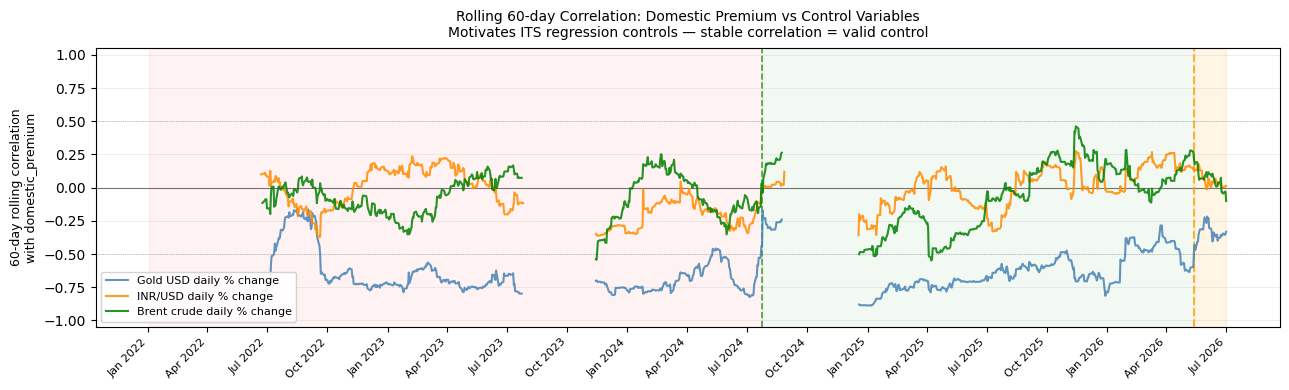

Saved → figures/fig03_rolling_correlations.png


In [6]:
# ── Cell 6: Rolling correlations — premium vs control variables ───────────
# Purpose: understand what drives domestic_premium variation.
# Motivates the ITS regression controls: delta_Gold_USD, delta_FX, delta_Oil.
# If rolling correlation is high and stable, the control belongs in the model.
# If it flips sign across regimes, we need an interaction term.
#
# Window: 60 trading days (~3 months) — enough to be stable, short enough
# to show regime-level shifts.

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

WINDOW = 60

# ── Compute rolling correlations ──────────────────────────────────────────
controls = {
    'delta_Gold_USD': ('Gold USD daily % change', 'steelblue'),
    'delta_FX':       ('INR/USD daily % change',  'darkorange'),
    'delta_Oil':      ('Brent crude daily % change', 'green'),
}

roll_corrs = {}
for col, (label, color) in controls.items():
    roll_corrs[col] = (
        df['domestic_premium']
        .rolling(WINDOW, min_periods=30)
        .corr(df[col]),
        label, color
    )

# ── Also compute static correlations by sub-period ────────────────────────
periods = {
    'High-duty':  df[df.index < DUTY_CUT],
    'Low-duty':   df[(df.index >= DUTY_CUT) & (df.index < POLICY_DATE)],
    'Post-hike':  df[df.index >= POLICY_DATE],
}

print('=== Static correlations: domestic_premium vs controls ===\n')
print(f'{"Variable":<25} {"High-duty":>12} {"Low-duty":>12} {"Post-hike":>12}')
print('─' * 65)
for col, (label, _) in controls.items():
    row = []
    for name, sub in periods.items():
        valid = sub[['domestic_premium', col]].dropna()
        r = valid['domestic_premium'].corr(valid[col]) if len(valid) > 5 else float('nan')
        row.append(f'{r:>+.3f}')
    print(f'{label:<25} {row[0]:>12} {row[1]:>12} {row[2]:>12}')

# ── Plot rolling correlations ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))

# Regime shading
ax.axvspan(df.index.min(), DUTY_CUT,      alpha=0.05, color='red')
ax.axvspan(DUTY_CUT,       POLICY_DATE,   alpha=0.05, color='green')
ax.axvspan(POLICY_DATE,    df.index.max(), alpha=0.10, color='orange')

ax.axhline(0,    color='black', lw=0.8, alpha=0.5)
ax.axhline(0.5,  color='grey',  lw=0.6, ls=':', alpha=0.6)
ax.axhline(-0.5, color='grey',  lw=0.6, ls=':', alpha=0.6)

ax.axvline(DUTY_CUT,    color='green',  lw=1.2, ls='--', alpha=0.7)
ax.axvline(POLICY_DATE, color='orange', lw=1.5, ls='--', alpha=0.8)

for col, (series, label, color) in roll_corrs.items():
    ax.plot(df.index, series, lw=1.5, label=f'{label}', color=color, alpha=0.85)

ax.set_ylabel(f'{WINDOW}-day rolling correlation\nwith domestic_premium', fontsize=9)
ax.set_title(f'Rolling {WINDOW}-day Correlation: Domestic Premium vs Control Variables\n'
             'Motivates ITS regression controls — stable correlation = valid control',
             fontsize=10, pad=8)
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45, ha='right', fontsize=8)
ax.set_ylim(-1.05, 1.05)
ax.legend(loc='lower left', fontsize=8, framealpha=0.85)
ax.grid(axis='y', alpha=0.3, lw=0.5)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig03_rolling_correlations.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/fig03_rolling_correlations.png')

=== Pre-trend test: OLS in low-duty window ===
  Window  : 2024-07-25 → 2026-05-12
  N       : 321 trading days
  Slope   : +0.78 INR/10g per trading day
  Slope/yr: +196 INR/10g per year
  p-value : 0.3469
  R²      : 0.0028

  ✓ No significant pre-trend (p=0.3469) — ITS assumption holds


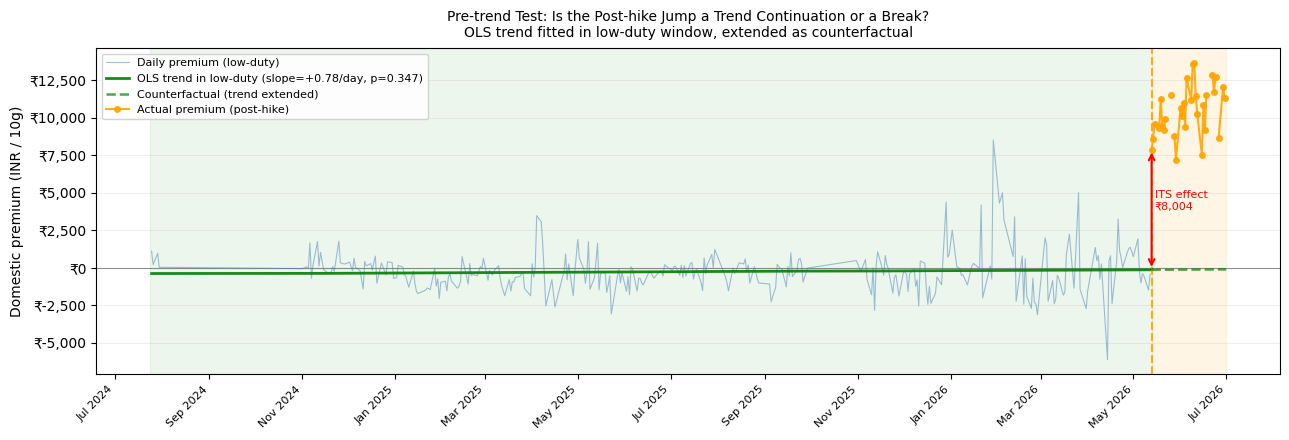

Saved → figures/fig04_pretrend_test.png


In [7]:
# ── Cell 7: Pre-trend test ────────────────────────────────────────────────
# Purpose: Test whether domestic_premium had a pre-existing trend in the
# low-duty window (Jul 2024 – May 12 2026) that would confound the ITS.
#
# ITS assumption: the outcome variable must be trending stably BEFORE the
# treatment. If premium was already rising before May 13, the post-hike
# jump could partly be a continuation of that trend, not a treatment effect.
#
# Two tests:
#   1. OLS regression of premium on time-trend within low-duty window only
#      H₀: slope = 0 (no pre-trend)
#   2. Visual: premium + fitted OLS line in low-duty window, extended
#      as a counterfactual into the post-hike window

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats

# ── Test 1: OLS on low-duty window ───────────────────────────────────────
low = df[(df.index >= DUTY_CUT) & (df.index < POLICY_DATE)][
    ['domestic_premium']].dropna().copy()
low['t'] = np.arange(len(low))

slope, intercept, r, p, se = stats.linregress(low['t'], low['domestic_premium'])

print('=== Pre-trend test: OLS in low-duty window ===')
print(f'  Window  : {low.index.min().date()} → {low.index.max().date()}')
print(f'  N       : {len(low)} trading days')
print(f'  Slope   : {slope:+.2f} INR/10g per trading day')
print(f'  Slope/yr: {slope * 252:+.0f} INR/10g per year')
print(f'  p-value : {p:.4f}')
print(f'  R²      : {r**2:.4f}')
print()
if p < 0.05:
    print(f'  ⚠ TREND DETECTED (p={p:.4f}) — slope = {slope:+.2f}/day')
    print(f'    Extrapolated to May 13: {intercept + slope*len(low):,.0f} INR/10g')
    print(f'    This trend would predict premium of ~{intercept + slope*len(low):,.0f}')
    print(f'    Actual Day 1 premium: {df.loc[df.index >= POLICY_DATE, "domestic_premium"].dropna().iloc[0]:,.0f}')
else:
    print(f'  ✓ No significant pre-trend (p={p:.4f}) — ITS assumption holds')

# ── Counterfactual extrapolation ──────────────────────────────────────────
# Extend the low-duty OLS line into the post-hike window
post = df[df.index >= POLICY_DATE][['domestic_premium']].copy()
n_post = len(post)
post['t_extrap'] = np.arange(len(low), len(low) + n_post)
post['counterfactual'] = intercept + slope * post['t_extrap']

# ── Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4.5))

# Regime shading (low-duty + post-hike only — zoom in)
zoom_start = DUTY_CUT
ax.axvspan(zoom_start,  POLICY_DATE,   alpha=0.07, color='green')
ax.axvspan(POLICY_DATE, df.index.max(), alpha=0.10, color='orange')
ax.axvline(POLICY_DATE, color='orange', lw=1.5, ls='--', alpha=0.9)
ax.axhline(0, color='black', lw=0.8, alpha=0.4)

# Actual premium (low-duty window)
ax.plot(low.index, low['domestic_premium'],
        color='steelblue', lw=0.8, alpha=0.5, label='Daily premium (low-duty)')

# OLS fitted line in low-duty window
fitted_x = low.index
fitted_y = intercept + slope * low['t']
ax.plot(fitted_x, fitted_y,
        color='green', lw=2.0, ls='-', alpha=0.9,
        label=f'OLS trend in low-duty (slope={slope:+.2f}/day, p={p:.3f})')

# Counterfactual extension into post-hike window
ax.plot(post.index, post['counterfactual'],
        color='green', lw=1.8, ls='--', alpha=0.7,
        label='Counterfactual (trend extended)')

# Actual premium (post-hike)
ax.plot(post.index, post['domestic_premium'],
        color='orange', lw=1.5, alpha=0.9, marker='o', ms=4,
        label='Actual premium (post-hike)')

# Treatment effect arrow on Day 1
day1_actual = df.loc[df.index >= POLICY_DATE, 'domestic_premium'].dropna().iloc[0]
day1_cf     = post['counterfactual'].iloc[0]
day1_date   = df.loc[df.index >= POLICY_DATE].index[0]
ax.annotate('', xy=(day1_date, day1_actual), xytext=(day1_date, day1_cf),
            arrowprops=dict(arrowstyle='<->', color='red', lw=1.5))
ax.text(day1_date + pd.DateOffset(days=2), (day1_actual + day1_cf) / 2,
        f'ITS effect\n₹{day1_actual - day1_cf:,.0f}', fontsize=8, color='red')

ax.set_ylabel('Domestic premium (INR / 10g)', fontsize=10)
ax.set_title('Pre-trend Test: Is the Post-hike Jump a Trend Continuation or a Break?\n'
             'OLS trend fitted in low-duty window, extended as counterfactual',
             fontsize=10, pad=8)
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 3, 5, 7, 9, 11]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45, ha='right', fontsize=8)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
ax.legend(loc='upper left', fontsize=8, framealpha=0.85)
ax.grid(axis='y', alpha=0.3, lw=0.5)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig04_pretrend_test.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/fig04_pretrend_test.png')

=== ADF Test: domestic_premium ===

  Full sample (Jan 2022 – Jun 2026)
    N          : 778
    ADF stat   : -1.1502
    p-value    : 0.6947   ⚠ UNIT ROOT (non-stationary)
    Lags used  : 6 (AIC selected)
    Crit vals  : 1%=-3.439  5%=-2.865  10%=-2.569

  Low-duty window only (Jul 2024 – May 2026)
    N          : 319
    ADF stat   : -9.3876
    p-value    : 0.0000   ✓ STATIONARY
    Lags used  : 1 (AIC selected)
    Crit vals  : 1%=-3.451  5%=-2.871  10%=-2.572

=== ADF Test: Gold_USD and rupees_per_dollar (expect I(1)) ===

  Gold_USD (levels)
    N          : 1115
    ADF stat   : -0.0364
    p-value    : 0.9554   ⚠ UNIT ROOT (non-stationary)
    Lags used  : 9 (AIC selected)
    Crit vals  : 1%=-3.436  5%=-2.864  10%=-2.568

  Gold_USD (first difference)
    N          : 1067
    ADF stat   : -8.4659
    p-value    : 0.0000   ✓ STATIONARY
    Lags used  : 10 (AIC selected)
    Crit vals  : 1%=-3.436  5%=-2.864  10%=-2.568

  rupees_per_dollar (levels)
    N          : 1164
   

/var/folders/dr/4hb3w_yn2xq77d2njhl6shph0000gn/T/ipykernel_10513/1093187040.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


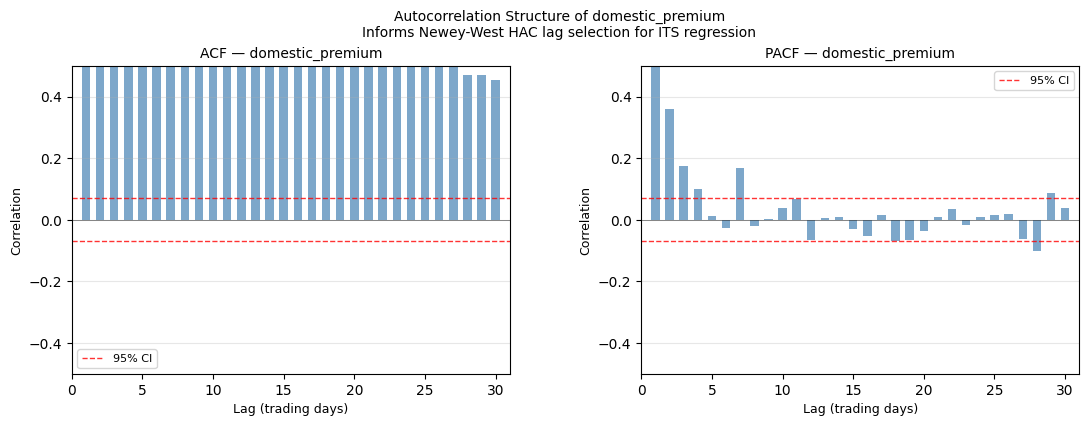


Saved → figures/fig05_acf_pacf.png


In [8]:
# ── Cell 8: Stationarity (ADF) + Autocorrelation ─────────────────────────
# Two purposes:
#   1. ADF test — is domestic_premium stationary (I(0)) or a random walk (I(1))?
#      Result determines whether ITS uses levels or first differences.
#   2. PACF — how many lags of autocorrelation exist in the premium?
#      Result sets the Newey-West HAC lag in the ITS regression.
#
# Also test Gold_USD and rupees_per_dollar — if I(1) but their combination
# is I(0), that justifies the ARDL cointegration test in Notebook 03.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from statsmodels.tsa.stattools import adfuller, acf, pacf

# ── Helper: run ADF and print result ─────────────────────────────────────
def run_adf(series, name, max_lags=10):
    s = series.dropna()
    result = adfuller(s, maxlag=max_lags, autolag='AIC')
    adf_stat, p_val, n_lags, n_obs = result[0], result[1], result[2], result[3]
    cv1, cv5, cv10 = result[4]['1%'], result[4]['5%'], result[4]['10%']
    status = '✓ STATIONARY' if p_val < 0.05 else '⚠ UNIT ROOT (non-stationary)'
    print(f'\n  {name}')
    print(f'    N          : {n_obs}')
    print(f'    ADF stat   : {adf_stat:.4f}')
    print(f'    p-value    : {p_val:.4f}   {status}')
    print(f'    Lags used  : {n_lags} (AIC selected)')
    print(f'    Crit vals  : 1%={cv1:.3f}  5%={cv5:.3f}  10%={cv10:.3f}')
    return p_val, adf_stat

# ── Test 1: domestic_premium — full sample and sub-periods ───────────────
print('=== ADF Test: domestic_premium ===')
prem = df['domestic_premium']

p_full, _ = run_adf(prem, 'Full sample (Jan 2022 – Jun 2026)')

low_prem  = prem[(df.index >= DUTY_CUT) & (df.index < POLICY_DATE)]
p_low, _  = run_adf(low_prem, 'Low-duty window only (Jul 2024 – May 2026)')

# ── Test 2: Gold_USD and FX — expect I(1) ────────────────────────────────
print('\n=== ADF Test: Gold_USD and rupees_per_dollar (expect I(1)) ===')
p_gold, _ = run_adf(df['Gold_USD'], 'Gold_USD (levels)')
p_gold_d, _= run_adf(df['Gold_USD'].diff(), 'Gold_USD (first difference)')

p_fx, _   = run_adf(df['rupees_per_dollar'], 'rupees_per_dollar (levels)')
p_fx_d, _ = run_adf(df['rupees_per_dollar'].diff(), 'rupees_per_dollar (first difference)')

# ── Test 3: Autocorrelation / PACF of domestic_premium ───────────────────
# This determines the Newey-West lag for ITS HAC standard errors.
# Rule of thumb: use PACF to find where autocorrelation cuts off.
print('\n=== Autocorrelation: domestic_premium ===')
prem_clean = prem.dropna()
n_lags_acf = 30

acf_vals  = acf(prem_clean,  nlags=n_lags_acf, fft=True)
pacf_vals = pacf(prem_clean, nlags=n_lags_acf)
ci = 1.96 / np.sqrt(len(prem_clean))  # 95% confidence band

print(f'  95% CI band : ±{ci:.3f}')
print(f'  PACF values at lags 1–10:')
for i in range(1, 11):
    sig = ' ← significant' if abs(pacf_vals[i]) > ci else ''
    print(f'    Lag {i:>2}: PACF={pacf_vals[i]:+.3f}{sig}')

# Suggested NW lag
nw_lags = int(np.ceil(len(prem_clean)**(1/4)))
print(f'\n  Newey-West rule-of-thumb lag: n^(1/4) = {nw_lags}')
sig_lags = [i for i in range(1, n_lags_acf+1) if abs(pacf_vals[i]) > ci]
print(f'  Significant PACF lags        : {sig_lags}')
print(f'  Recommended NW lag for ITS   : max({nw_lags}, {max(sig_lags) if sig_lags else 1}) '
      f'= {max(nw_lags, max(sig_lags) if sig_lags else 1)}')

# ── Plot: ACF + PACF ──────────────────────────────────────────────────────
fig = plt.figure(figsize=(13, 4))
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.3)

for idx, (vals, title) in enumerate([
        (acf_vals[1:],  'ACF — domestic_premium'),
        (pacf_vals[1:], 'PACF — domestic_premium')]):
    ax = fig.add_subplot(gs[idx])
    lags = np.arange(1, len(vals) + 1)
    ax.bar(lags, vals, color='steelblue', alpha=0.7, width=0.6)
    ax.axhline(ci,  color='red', ls='--', lw=1.0, alpha=0.8, label='95% CI')
    ax.axhline(-ci, color='red', ls='--', lw=1.0, alpha=0.8)
    ax.axhline(0,   color='black', lw=0.6, alpha=0.5)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Lag (trading days)', fontsize=9)
    ax.set_ylabel('Correlation', fontsize=9)
    ax.set_xlim(0, n_lags_acf + 1)
    ax.set_ylim(-0.5, 0.5)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Autocorrelation Structure of domestic_premium\n'
             'Informs Newey-West HAC lag selection for ITS regression',
             fontsize=10, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig05_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nSaved → figures/fig05_acf_pacf.png')

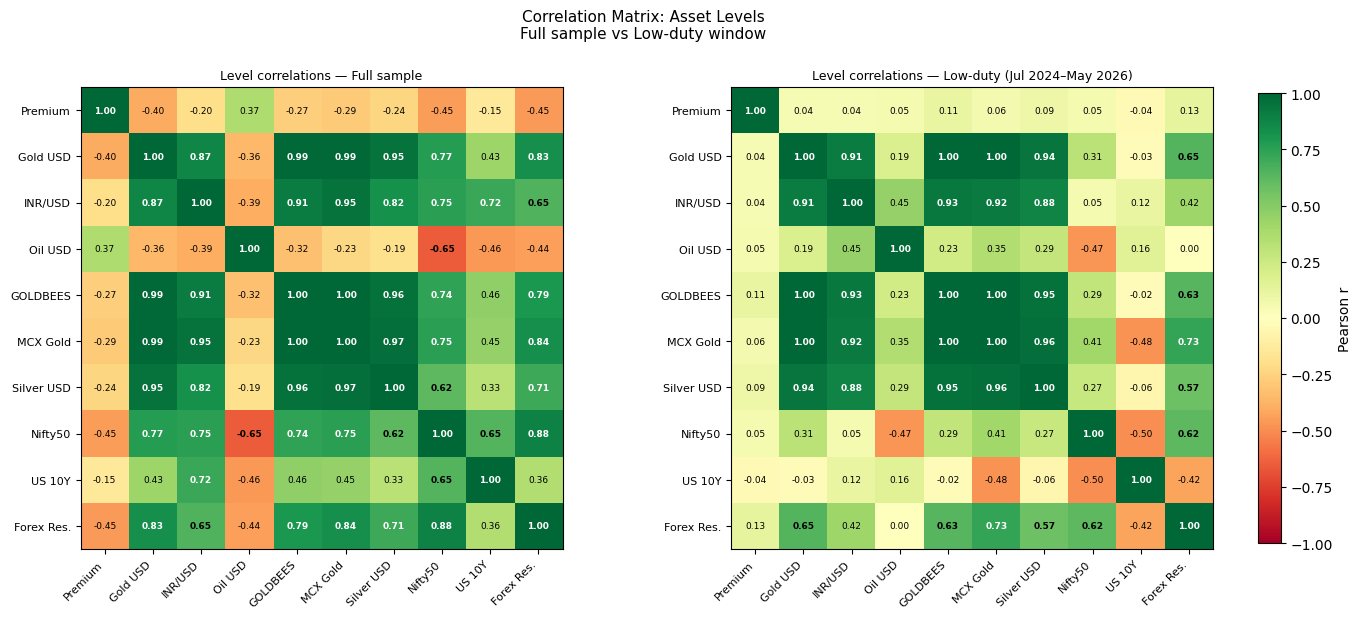

Saved → figures/fig06a_corr_levels.png


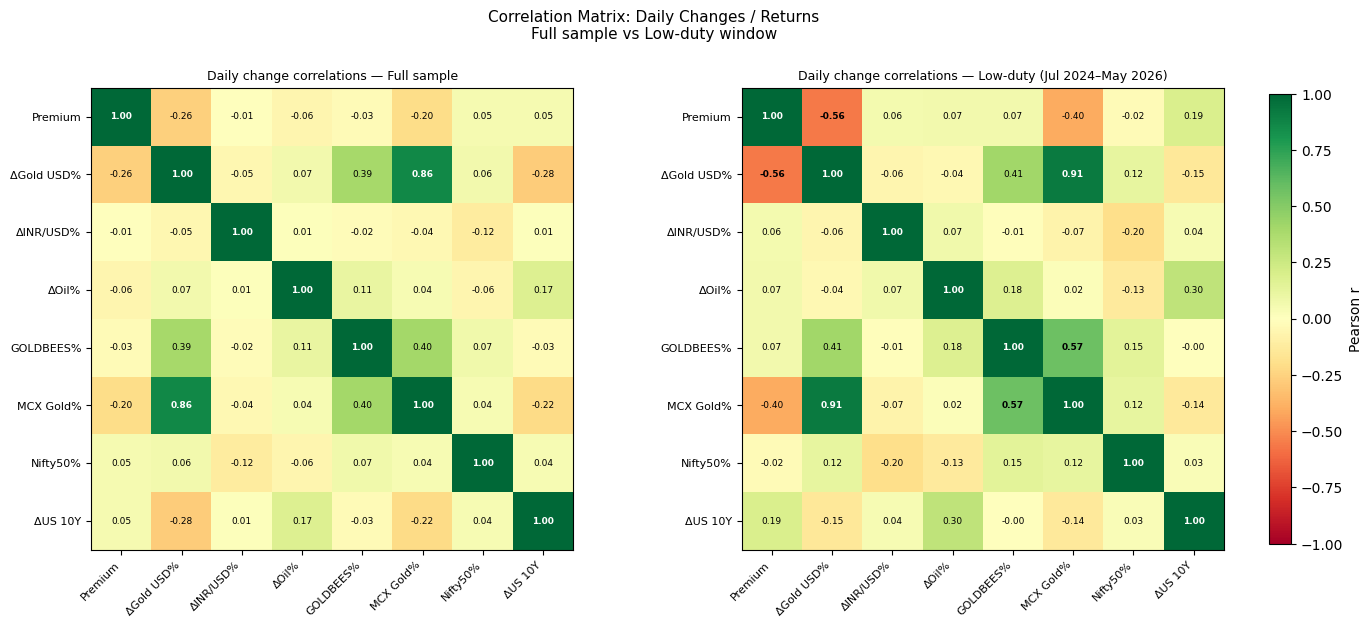

Saved → figures/fig06b_corr_changes.png

=== Key correlations WITH domestic_premium ===

Variable                   Full sample     Low-duty    Post-hike
─────────────────────────────────────────────────────────────────
Gold USD (level)                -0.402       +0.042       -0.612
MCX Gold (level)                -0.287       +0.062       -0.540
GOLDBEES (level)                -0.272       +0.112       -0.435
Oil USD (level)                 +0.366       +0.050       -0.299
INR/USD (level)                 -0.197       +0.041       -0.337
Nifty50 (level)                 -0.450       +0.051       -0.041
US 10Y yield                    -0.148       -0.037       +0.141
Forex reserves                  -0.453       +0.129       -0.324

=== Multicollinearity check: ITS controls vs each other ===

                delta_Gold_USD  delta_FX  delta_Oil
delta_Gold_USD             1.0      -0.1        0.1
delta_FX                  -0.1       1.0        0.0
delta_Oil                  0.1       0.0  

In [9]:
# ── Cell 9: Correlation matrix — all key variables ────────────────────────
import matplotlib.pyplot as plt
import numpy as np

level_vars = [
    'domestic_premium', 'Gold_USD', 'rupees_per_dollar', 'Oil_USD',
    'GOLDBEES', 'MCX_Gold_close', 'Silver_USD', 'Nifty50',
    'US10Y_yield', 'forex_reserves_usd_bn'
]
var_labels_level = [
    'Premium', 'Gold USD', 'INR/USD', 'Oil USD',
    'GOLDBEES', 'MCX Gold', 'Silver USD', 'Nifty50',
    'US 10Y', 'Forex Res.'
]
var_labels_change = [
    'Premium', 'ΔGold USD%', 'ΔINR/USD%', 'ΔOil%',
    'GOLDBEES%', 'MCX Gold%', 'Nifty50%', 'ΔUS 10Y'
]

def plot_corr(ax, corr_matrix, labels, title):
    n = len(labels)
    im = ax.imshow(corr_matrix, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_title(title, fontsize=9, pad=6)
    for i in range(n):
        for j in range(n):
            val = corr_matrix.iloc[i, j]
            if not np.isnan(val):
                color = 'white' if abs(val) > 0.7 else 'black'
                ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                        fontsize=6.5, color=color,
                        fontweight='bold' if abs(val) > 0.5 else 'normal')
    return im

# ── Figure 1: Level correlations ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, (name, sub) in zip(axes, {
        'Full sample': df,
        'Low-duty (Jul 2024–May 2026)': df[(df.index >= DUTY_CUT) & (df.index < POLICY_DATE)]
}.items()):
    corr = sub[level_vars].corr()
    im = plot_corr(ax, corr, var_labels_level, f'Level correlations — {name}')
fig.suptitle('Correlation Matrix: Asset Levels\nFull sample vs Low-duty window',
             fontsize=11, y=1.01)
fig.subplots_adjust(right=0.88, wspace=0.35)
cax = fig.add_axes([0.91, 0.12, 0.015, 0.75])
fig.colorbar(im, cax=cax, label='Pearson r')
plt.savefig(FIG_DIR / 'fig06a_corr_levels.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/fig06a_corr_levels.png')

# ── Figure 2: Daily change correlations ───────────────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(15, 6))
for ax, (name, sub) in zip(axes2, {
        'Full sample': df,
        'Low-duty (Jul 2024–May 2026)': df[(df.index >= DUTY_CUT) & (df.index < POLICY_DATE)]
}.items()):
    sub2 = sub[['domestic_premium', 'delta_Gold_USD', 'delta_FX', 'delta_Oil',
                 'GOLDBEES', 'MCX_Gold_close', 'Nifty50', 'US10Y_yield']].copy()
    sub2['GOLDBEES']       = sub2['GOLDBEES'].pct_change() * 100
    sub2['MCX_Gold_close'] = sub2['MCX_Gold_close'].pct_change() * 100
    sub2['Nifty50']        = sub2['Nifty50'].pct_change() * 100
    sub2['US10Y_yield']    = sub2['US10Y_yield'].diff()
    corr2 = sub2.corr()
    im2 = plot_corr(ax, corr2, var_labels_change, f'Daily change correlations — {name}')
# NEW:
fig2.suptitle('Correlation Matrix: Daily Changes / Returns\nFull sample vs Low-duty window',
              fontsize=11, y=1.01)
fig2.subplots_adjust(right=0.88, wspace=0.35)
cax2 = fig2.add_axes([0.91, 0.12, 0.015, 0.75])
fig2.colorbar(im2, cax=cax2, label='Pearson r')
plt.savefig(FIG_DIR / 'fig06b_corr_changes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/fig06b_corr_changes.png')

# ── Key correlations with domestic_premium ────────────────────────────────
regimes = {
    'Full sample':  df,
    'Low-duty':     df[(df.index >= DUTY_CUT) & (df.index < POLICY_DATE)],
    'Post-hike':    df[df.index >= POLICY_DATE],
}
check_vars = {
    'Gold_USD':            'Gold USD (level)',
    'MCX_Gold_close':      'MCX Gold (level)',
    'GOLDBEES':            'GOLDBEES (level)',
    'Oil_USD':             'Oil USD (level)',
    'rupees_per_dollar':   'INR/USD (level)',
    'Nifty50':             'Nifty50 (level)',
    'US10Y_yield':         'US 10Y yield',
    'forex_reserves_usd_bn': 'Forex reserves',
}
print('\n=== Key correlations WITH domestic_premium ===\n')
print(f'{"Variable":<25} {"Full sample":>12} {"Low-duty":>12} {"Post-hike":>12}')
print('─' * 65)
for col, label in check_vars.items():
    row = []
    for name, sub in regimes.items():
        valid = sub[['domestic_premium', col]].dropna()
        r = valid['domestic_premium'].corr(valid[col]) if len(valid) > 5 else float('nan')
        row.append(f'{r:>+.3f}')
    print(f'{label:<25} {row[0]:>12} {row[1]:>12} {row[2]:>12}')

print('\n=== Multicollinearity check: ITS controls vs each other ===\n')
ctrl = df[['delta_Gold_USD', 'delta_FX', 'delta_Oil']].dropna()
print(ctrl.corr().round(3).to_string())
print('\n✓ Concern if |r| > 0.7 between controls')


Low-duty window: N=321, mean=-257, std=1374
Q1=-997, Q3=270, IQR=1267
IQR fences: lower=-2898, upper=2171

IQR outliers (16 obs):
            domestic_premium  Gold_USD  rupees_per_dollar
date                                                     
2025-04-04           3,472.6   3,012.0               85.3
2025-04-07           3,060.0   2,951.3               85.5
2025-05-23          -3,082.6   3,363.6               86.0
2025-12-29           4,374.1   4,325.1               89.8
2026-01-02           2,507.7   4,314.4               90.0
2026-01-21           4,185.4   4,831.8               91.1
2026-01-29           8,516.2   5,318.4               92.0
2026-02-02           4,308.1   4,622.5               91.7
2026-02-04           4,998.4   4,920.4               90.4
2026-02-05           3,187.1   4,861.4               90.1
2026-02-12           3,396.8   4,923.7               90.7
2026-02-27          -3,127.5   5,230.5               91.0
2026-03-20           2,234.7   4,570.4               93.1


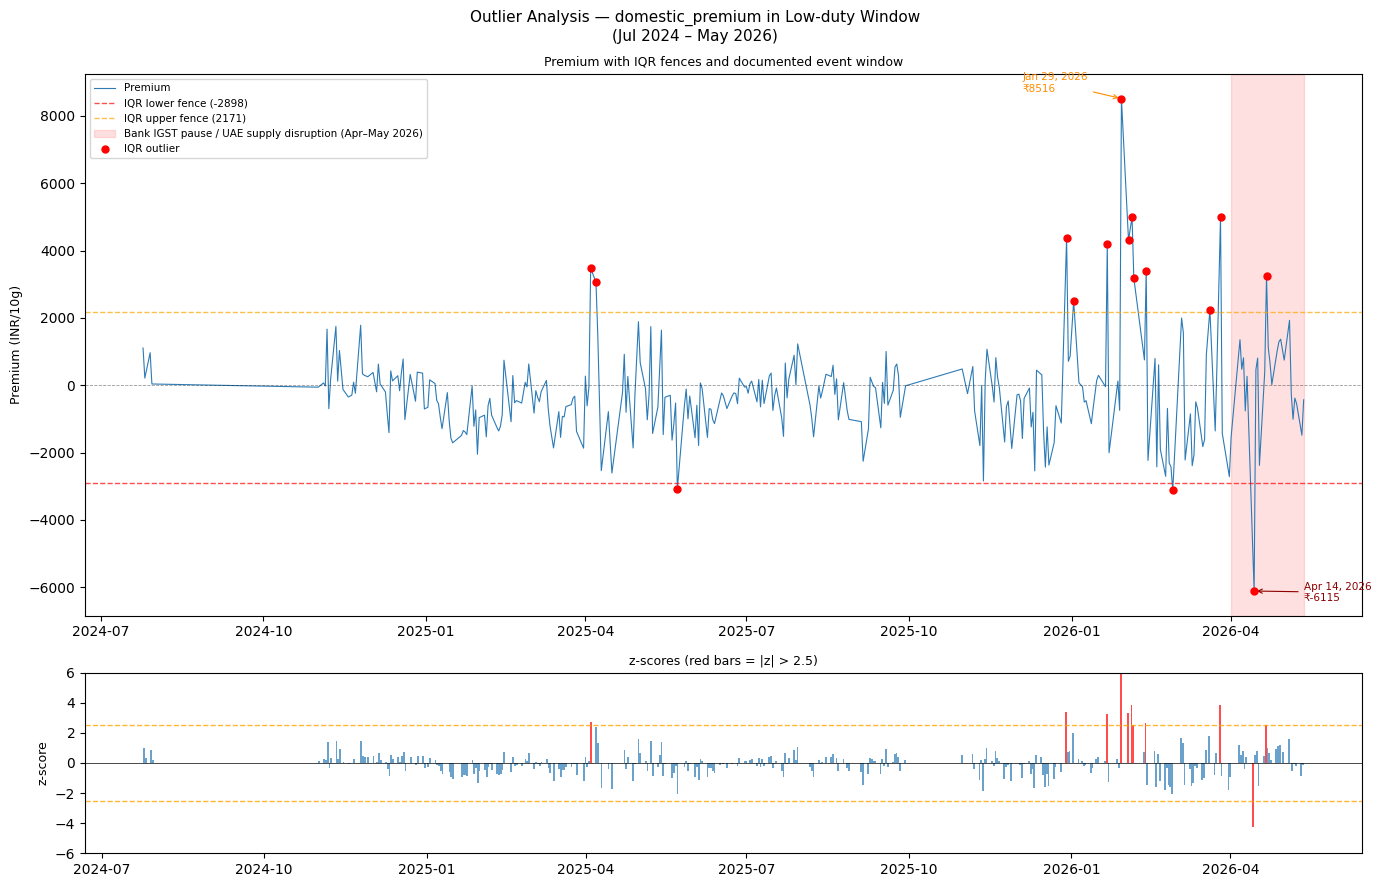


OUTLIER TREATMENT DECISION
  IQR outliers:    16 obs
  |z| > 2.5:       11 obs
  Outliers IN event window (Apr–May 2026): 2
  Outliers OUTSIDE event window:           14

Decision (pre-registered):
  KEEP all outliers in MAIN ITS specification
  (removing them would understate the pre-hike noise baseline and bias
   the ITS intercept shift estimate upward)

  ADD 'pre_restriction' dummy (Apr 1 – May 12 2026) in the ITS
  regression as a documented-event control → Cell 12 feature engineering

  TEST sensitivity WITHOUT event-window observations in Notebook 05
  robustness checks



In [10]:
# ── Cell 10: Outlier analysis ─────────────────────────────────────────────
# Focus: domestic_premium in the low-duty window
# Methods: IQR (Tukey fences) + z-score
# Purpose: formally identify, date, and decide treatment of extreme values

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

LOW_DUTY_MASK = (df.index >= DUTY_CUT) & (df.index < POLICY_DATE)
df_low = df[LOW_DUTY_MASK & df['domestic_premium'].notna()].copy()

# ── 1. IQR method (Tukey fences) ─────────────────────────────────────────
Q1  = df_low['domestic_premium'].quantile(0.25)
Q3  = df_low['domestic_premium'].quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

# ── 2. z-score method ────────────────────────────────────────────────────
mu    = df_low['domestic_premium'].mean()
sigma = df_low['domestic_premium'].std()
df_low['z_score'] = (df_low['domestic_premium'] - mu) / sigma

iqr_outliers    = df_low[(df_low['domestic_premium'] < lower_fence) |
                          (df_low['domestic_premium'] > upper_fence)]
zscore_outliers = df_low[df_low['z_score'].abs() > 2.5]

print(f"Low-duty window: N={len(df_low)}, mean={mu:.0f}, std={sigma:.0f}")
print(f"Q1={Q1:.0f}, Q3={Q3:.0f}, IQR={IQR:.0f}")
print(f"IQR fences: lower={lower_fence:.0f}, upper={upper_fence:.0f}")

print(f"\nIQR outliers ({len(iqr_outliers)} obs):")
print(iqr_outliers[['domestic_premium', 'Gold_USD', 'rupees_per_dollar']].to_string())

print(f"\nz-score > 2.5 outliers ({len(zscore_outliers)} obs):")
print(zscore_outliers[['domestic_premium', 'z_score', 'Gold_USD', 'rupees_per_dollar']].round(2).to_string())

# ── 3. Time-series plot with outliers flagged ─────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 9),
                          gridspec_kw={'height_ratios': [3, 1]})
fig.suptitle('Outlier Analysis — domestic_premium in Low-duty Window\n(Jul 2024 – May 2026)',
             fontsize=11)

ax = axes[0]
ax.plot(df_low.index, df_low['domestic_premium'],
        color='#2c7bb6', linewidth=0.8, zorder=2, label='Premium')
ax.axhline(0, color='black', linewidth=0.6, linestyle='--', alpha=0.4)
ax.axhline(lower_fence, color='red', linewidth=1.0, linestyle='--', alpha=0.7,
           label=f'IQR lower fence ({lower_fence:.0f})')
ax.axhline(upper_fence, color='orange', linewidth=1.0, linestyle='--', alpha=0.7,
           label=f'IQR upper fence ({upper_fence:.0f})')

# Shade the documented event window (Apr 1 – May 12 2026)
event_start = pd.Timestamp('2026-04-01')
event_end   = pd.Timestamp('2026-05-12')
ax.axvspan(event_start, event_end, alpha=0.12, color='red',
           label='Bank IGST pause / UAE supply disruption (Apr–May 2026)')

# Mark IQR outliers
ax.scatter(iqr_outliers.index, iqr_outliers['domestic_premium'],
           color='red', s=25, zorder=5, label='IQR outlier', marker='o')

# Annotate the absolute minimum
min_idx = df_low['domestic_premium'].idxmin()
min_val = df_low.loc[min_idx, 'domestic_premium']
ax.annotate(f'{min_idx.strftime("%b %d, %Y")}\n₹{min_val:.0f}',
            xy=(min_idx, min_val),
            xytext=(min_idx + pd.offsets.BusinessDay(20), min_val - 300),
            fontsize=7.5, color='darkred',
            arrowprops=dict(arrowstyle='->', color='darkred', lw=0.8))

# Annotate the absolute maximum
max_idx = df_low['domestic_premium'].idxmax()
max_val = df_low.loc[max_idx, 'domestic_premium']
ax.annotate(f'{max_idx.strftime("%b %d, %Y")}\n₹{max_val:.0f}',
            xy=(max_idx, max_val),
            xytext=(max_idx - pd.offsets.BusinessDay(40), max_val + 200),
            fontsize=7.5, color='darkorange',
            arrowprops=dict(arrowstyle='->', color='darkorange', lw=0.8))

ax.set_ylabel('Premium (INR/10g)', fontsize=9)
ax.legend(fontsize=7.5, loc='upper left')
ax.set_title('Premium with IQR fences and documented event window', fontsize=9)

# Bottom panel: z-scores
ax2 = axes[1]
colors = ['red' if abs(z) > 2.5 else '#2c7bb6' for z in df_low['z_score']]
ax2.bar(df_low.index, df_low['z_score'], color=colors, width=1, alpha=0.7)
ax2.axhline( 2.5, color='orange', linewidth=1.0, linestyle='--', alpha=0.8)
ax2.axhline(-2.5, color='orange', linewidth=1.0, linestyle='--', alpha=0.8)
ax2.axhline(0, color='black', linewidth=0.5)
ax2.set_ylabel('z-score', fontsize=9)
ax2.set_title('z-scores (red bars = |z| > 2.5)', fontsize=9)
ax2.set_ylim(-6, 6)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig07_outlier_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 4. Decision summary ───────────────────────────────────────────────────
out_in_event  = iqr_outliers[iqr_outliers.index >= event_start]
out_outside   = iqr_outliers[iqr_outliers.index <  event_start]
print("\n" + "="*60)
print("OUTLIER TREATMENT DECISION")
print("="*60)
print(f"  IQR outliers:    {len(iqr_outliers)} obs")
print(f"  |z| > 2.5:       {len(zscore_outliers)} obs")
print(f"  Outliers IN event window (Apr–May 2026): {len(out_in_event)}")
print(f"  Outliers OUTSIDE event window:           {len(out_outside)}")
print("""
Decision (pre-registered):
  KEEP all outliers in MAIN ITS specification
  (removing them would understate the pre-hike noise baseline and bias
   the ITS intercept shift estimate upward)

  ADD 'pre_restriction' dummy (Apr 1 – May 12 2026) in the ITS
  regression as a documented-event control → Cell 12 feature engineering

  TEST sensitivity WITHOUT event-window observations in Notebook 05
  robustness checks
""")


Paired obs (both MCX & IBJA non-null): 822
  High-duty: 453
  Low-duty:  336
  Post-hike: 33

── Pearson r: MCX_Gold_close vs Gold_INR_PM ──
  Full sample     N= 822  r=0.9994  p=0.00e+00  MCX-IBJA spread: mean=+158  std=1296
  High-duty       N= 453  r=0.9945  p=0.00e+00  MCX-IBJA spread: mean=-111  std=742
  Low-duty        N= 336  r=0.9984  p=0.00e+00  MCX-IBJA spread: mean=+354  std=1651
  Post-hike       N=  33  r=0.9699  p=1.39e-20  MCX-IBJA spread: mean=+1844  std=1561

── OLS: Gold_INR_PM ~ MCX_Gold_close ──
  High-duty       slope=0.9922  intercept=+571  R²=0.9891
  Low-duty        slope=0.9852  intercept=+1264  R²=0.9968
  Post-hike       slope=0.9892  intercept=-178  R²=0.9407


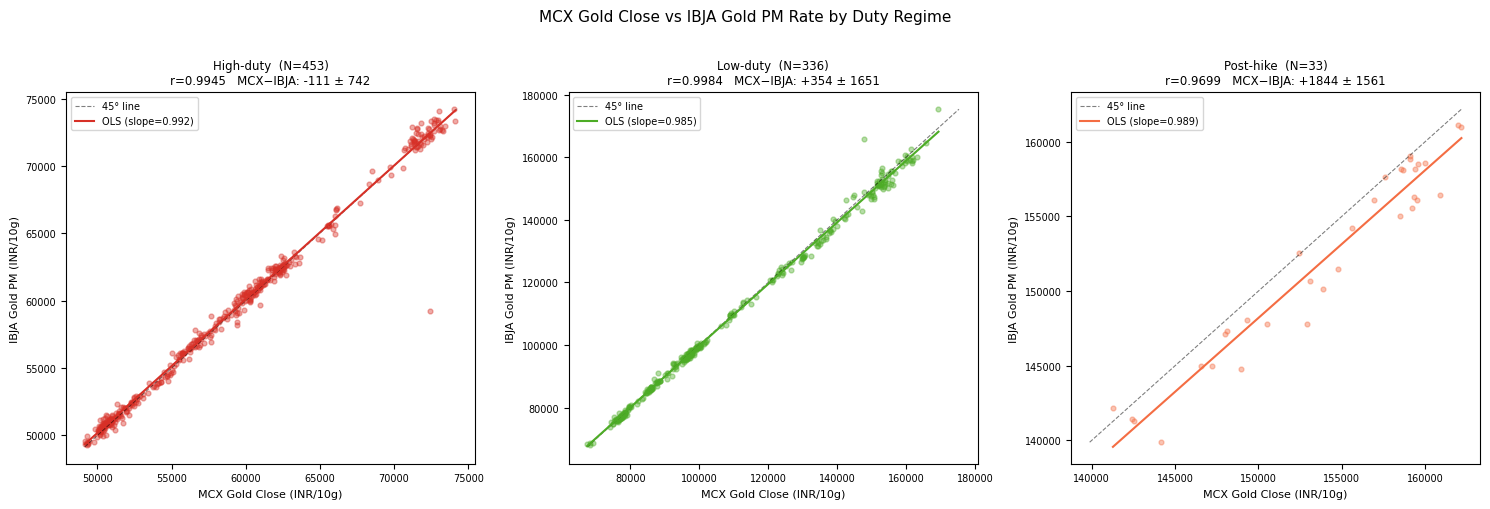

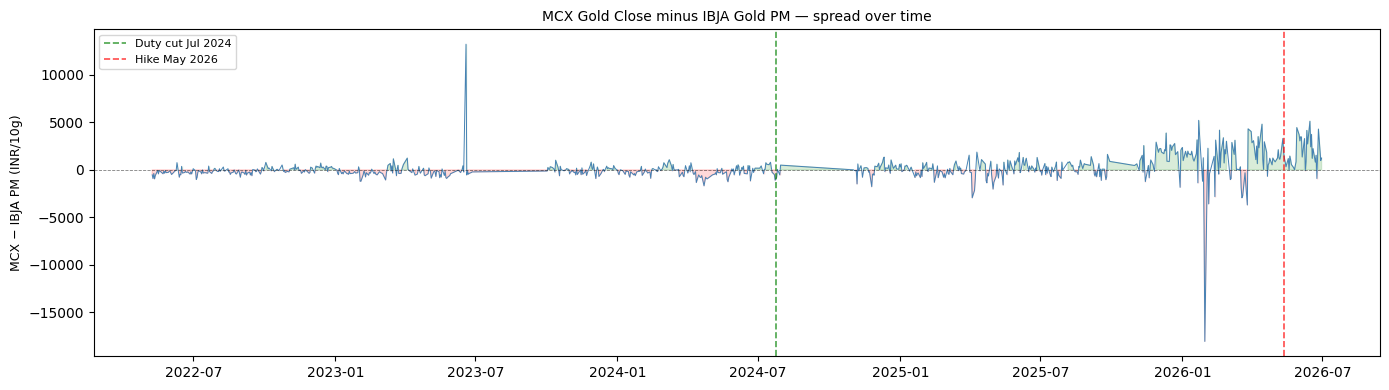

In [11]:
# ── Cell 11: MCX Gold vs IBJA PM — scatter + correlation by regime ────────
# Purpose: validate that MCX closing price tracks IBJA PM rate;
#          check if the relationship changes pre/post hike

import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
from scipy import stats

# ── Paired sample (both columns non-null) ────────────────────────────────
df_pair = df[['Gold_INR_PM', 'MCX_Gold_close']].dropna().copy()

# Regime masks on the paired sample
mask_high = df_pair.index < DUTY_CUT
mask_low  = (df_pair.index >= DUTY_CUT) & (df_pair.index < POLICY_DATE)
mask_post = df_pair.index >= POLICY_DATE

print(f"Paired obs (both MCX & IBJA non-null): {len(df_pair)}")
print(f"  High-duty: {mask_high.sum()}")
print(f"  Low-duty:  {mask_low.sum()}")
print(f"  Post-hike: {mask_post.sum()}")

# ── Correlations ─────────────────────────────────────────────────────────
print("\n── Pearson r: MCX_Gold_close vs Gold_INR_PM ──")
for name, mask in [('Full sample', slice(None)),
                    ('High-duty',  mask_high),
                    ('Low-duty',   mask_low),
                    ('Post-hike',  mask_post)]:
    sub = df_pair[mask] if not isinstance(mask, slice) else df_pair
    r, p = stats.pearsonr(sub['MCX_Gold_close'], sub['Gold_INR_PM'])
    spread_mean = (sub['MCX_Gold_close'] - sub['Gold_INR_PM']).mean()
    spread_std  = (sub['MCX_Gold_close'] - sub['Gold_INR_PM']).std()
    print(f"  {name:<15} N={len(sub):>4}  r={r:.4f}  p={p:.2e}  "
          f"MCX-IBJA spread: mean={spread_mean:+.0f}  std={spread_std:.0f}")

# ── OLS fit per regime ───────────────────────────────────────────────────
print("\n── OLS: Gold_INR_PM ~ MCX_Gold_close ──")
for name, mask in [('High-duty', mask_high),
                    ('Low-duty',  mask_low),
                    ('Post-hike', mask_post)]:
    sub = df_pair[mask]
    if len(sub) < 5:
        continue
    slope, intercept, r, p, se = stats.linregress(sub['MCX_Gold_close'],
                                                    sub['Gold_INR_PM'])
    print(f"  {name:<15} slope={slope:.4f}  intercept={intercept:+.0f}  R²={r**2:.4f}")

# ── Figure ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('MCX Gold Close vs IBJA Gold PM Rate by Duty Regime',
             fontsize=11, y=1.01)

palette = {'High-duty': '#d73027', 'Low-duty': '#4dac26', 'Post-hike': '#f46d43'}

for ax, (name, mask) in zip(axes, [('High-duty',  mask_high),
                                     ('Low-duty',   mask_low),
                                     ('Post-hike',  mask_post)]):
    sub = df_pair[mask]
    if len(sub) < 5:
        ax.set_visible(False)
        continue

    color = palette[name]
    ax.scatter(sub['MCX_Gold_close'], sub['Gold_INR_PM'],
               color=color, alpha=0.4, s=12, zorder=2)

    # 45-degree perfect-tracking line
    mn = min(sub['MCX_Gold_close'].min(), sub['Gold_INR_PM'].min())
    mx = max(sub['MCX_Gold_close'].max(), sub['Gold_INR_PM'].max())
    ax.plot([mn, mx], [mn, mx], 'k--', linewidth=0.8, alpha=0.5, label='45° line')

    # OLS fit line
    slope, intercept, r, _, _ = stats.linregress(sub['MCX_Gold_close'],
                                                   sub['Gold_INR_PM'])
    x_fit = np.linspace(sub['MCX_Gold_close'].min(), sub['MCX_Gold_close'].max(), 100)
    ax.plot(x_fit, slope * x_fit + intercept, color=color, linewidth=1.5,
            label=f'OLS (slope={slope:.3f})')

    spread = sub['MCX_Gold_close'] - sub['Gold_INR_PM']
    ax.set_title(f'{name}  (N={len(sub)})\n'
                 f'r={r:.4f}   MCX−IBJA: {spread.mean():+.0f} ± {spread.std():.0f}',
                 fontsize=8.5)
    ax.set_xlabel('MCX Gold Close (INR/10g)', fontsize=8)
    ax.set_ylabel('IBJA Gold PM (INR/10g)', fontsize=8)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig08_mcx_vs_ibja.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Time series of MCX-IBJA spread ────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(14, 4))
spread_ts = df_pair['MCX_Gold_close'] - df_pair['Gold_INR_PM']
ax2.plot(spread_ts.index, spread_ts, color='steelblue', linewidth=0.7)
ax2.axhline(0, color='black', linewidth=0.6, linestyle='--', alpha=0.5)
ax2.axvline(DUTY_CUT,    color='green',  linewidth=1.2, linestyle='--', alpha=0.7, label='Duty cut Jul 2024')
ax2.axvline(POLICY_DATE, color='red',    linewidth=1.2, linestyle='--', alpha=0.7, label='Hike May 2026')
ax2.fill_between(spread_ts.index, spread_ts, 0,
                  where=spread_ts > 0, alpha=0.15, color='green')
ax2.fill_between(spread_ts.index, spread_ts, 0,
                  where=spread_ts < 0, alpha=0.15, color='red')
ax2.set_ylabel('MCX − IBJA PM (INR/10g)', fontsize=9)
ax2.set_title('MCX Gold Close minus IBJA Gold PM — spread over time', fontsize=10)
ax2.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig08b_mcx_ibja_spread.png', dpi=150, bbox_inches='tight')
plt.show()


In [12]:
# ── Cell 12: Feature engineering — append to gold_policy_clean.csv ──────
# Features added:
#   t               — integer trading-day counter from dataset start (ITS trend term)
#   pre_restriction — 1 if Apr 1 – May 12 2026 (bank IGST pause / UAE disruption)
#   lag1_premium    — domestic_premium lagged 1 trading day (AR(1) control option)

# ── 1. Time trend t ───────────────────────────────────────────────────────
# t = 0 at first row of full dataset; increments by 1 per trading day
df["t"] = range(len(df))

# ── 2. pre_restriction dummy ──────────────────────────────────────────────
# Covers the documented confound window immediately before the hike:
# 17 banks paused bullion imports (IGST dispute) + UAE supply disruption
PRE_RESTRICTION_START = pd.Timestamp("2026-04-01")
PRE_RESTRICTION_END   = pd.Timestamp("2026-05-12")  # day before hike
df["pre_restriction"] = (
    (df.index >= PRE_RESTRICTION_START) & (df.index <= PRE_RESTRICTION_END)
).astype(int)

# ── 3. Lagged premium ─────────────────────────────────────────────────────
# 1-day lag — optional AR(1) control for the ITS regression
df["lag1_premium"] = df["domestic_premium"].shift(1)


# ── 4. lag_break flag ─────────────────────────────────────────────────────
# Flags IBJA observations preceded by a >5 calendar-day gap from the
# previous IBJA observation (PDF or BullionWorld). Used in robustness
# checks to exclude lag-contaminated observations from the AR(1) control.
_ibja_obs  = df[df["ibja_source"].notna()].index
_gaps      = pd.Series(_ibja_obs, index=_ibja_obs).diff().dt.days
_lag_dates = _gaps[_gaps > 5].index
df["lag_break"] = 0
df.loc[df.index.isin(_lag_dates), "lag_break"] = 1
print(f"  lag_break: {df['lag_break'].sum()} observations flagged (>5-day gap from prev IBJA)")

# ── 5. Verify new columns ─────────────────────────────────────────────────
# ── 6. Verify new columns ─────────────────────────────────────────────────
t_min = df["t"].min()
t_max = df["t"].max()
t_n   = df["t"].notna().sum()
pr_n  = df["pre_restriction"].sum()
lag_ok  = df["lag1_premium"].notna().sum()
lag_nan = df["lag1_premium"].isna().sum()

print("=== New feature columns ===")
print("  lag_break:       " + str(df["lag_break"].sum()) + " flagged")
print("  t:               " + str(t_min) + " to " + str(t_max) + "  (N=" + str(t_n) + ")")
print("  pre_restriction: " + str(pr_n) + " obs flagged")

pr = df[df["pre_restriction"] == 1]
if len(pr):
    print("  pre_restriction dates: " + str(pr.index[0].date()) + " to " + str(pr.index[-1].date()))

print("  lag1_premium:    " + str(lag_ok) + " non-null  (" + str(lag_nan) + " NaN - first row only)")

# Show a sample spanning the pre_restriction and post_hike window
check_cols = ["domestic_premium", "lag1_premium", "t",
              "pre_restriction", "post_hike", "delta_Gold_USD", "delta_FX"]
print("")
print("--- Sample rows around policy window (Apr 1 - May 20 2026) ---")
window = df.loc["2026-04-01":"2026-05-20", check_cols]
print(window.to_string())

# ── 7. Save back to CSV (clean + versioned) ──────────────────────────────
out_path = DATA_DIR / "gold_policy_clean.csv"
df.to_csv(out_path)
df.to_csv(DATA_DIR / f"gold_policy_{DATASET_VERSION}.csv")
print("")
print("Saved: " + str(out_path))
print("Saved: " + str(DATA_DIR / f"gold_policy_{DATASET_VERSION}.csv"))
print("Shape: " + str(df.shape))
print("Columns (" + str(len(df.columns)) + "): " + str(list(df.columns)))


  lag_break: 8 observations flagged (>5-day gap from prev IBJA)
=== New feature columns ===
  lag_break:       8 flagged
  t:               0 to 1170  (N=1171)
  pre_restriction: 30 obs flagged
  pre_restriction dates: 2026-04-01 to 2026-05-12
  lag1_premium:    785 non-null  (386 NaN - first row only)

--- Sample rows around policy window (Apr 1 - May 20 2026) ---
            domestic_premium  lag1_premium     t  pre_restriction  post_hike  delta_Gold_USD  delta_FX
date                                                                                                  
2026-04-01          -1,536.1      -2,716.5  1105                1          0             2.9      -0.9
2026-04-02               NaN      -1,536.1  1106                1          0            -2.8      -0.9
2026-04-03               NaN           NaN  1107                1          0             NaN       0.4
2026-04-06           1,351.6           NaN  1108                1          0             NaN      -0.0
2026-04-07    

=== July 2024 Duty Cut Event Study ===
Last pre-cut premium (Jul 23 2024):    INR 1035/10g
Mean premium (last 20 pre-cut days):   INR 4804/10g
Target equilibrium (6% duty):          INR ~0
Shock to absorb:                        INR 1035

Date            Day     IBJA PM    Parity6%     Premium   % Collapsed
-----------------------------------------------------------------
2024-07-25        0      68227      67122       1105        -6.8%
2024-07-26        1      68131      67919        212        79.6%
2024-07-29        2      68800      67834        966         6.7%
2024-07-30        3      68680      68643         37        96.5%
2024-11-01        4      78425      78483        -58       105.6%
2024-11-04        5      78518      78451         67        93.5%
2024-11-05        6      78566      78589        -23       102.2%
2024-11-06        7      78136      76471       1665       -60.9%
2024-11-07        8      76780      77478       -698       167.5%
2024-11-08        9      77382 

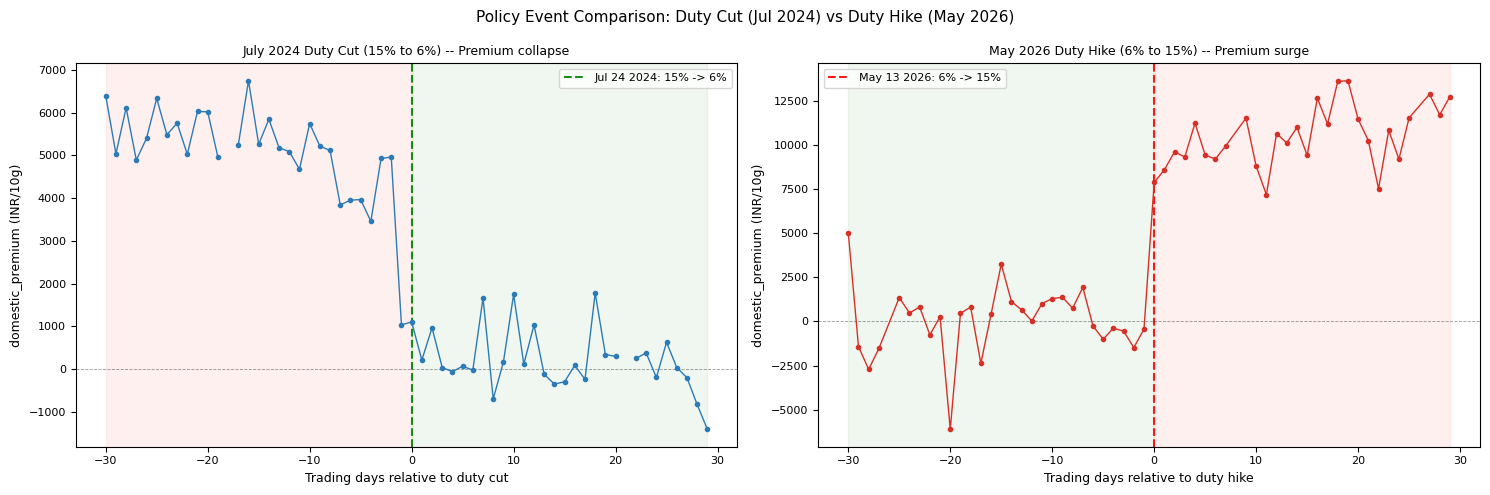


=== Speed comparison: Cut (2024) vs Hike (2026) ===
  CUT  (2024, week 1): 56.3% collapsed
  CUT  (2024, day 1): -6.8% collapsed
  HIKE (2026, day 1): 67.4% passed through
  HIKE (2026, 20 days): 83.7% passed through (Cell 5)


In [13]:
# ── Cell 13: July 2024 duty cut event study ──────────────────────────────
# Mirror of Cell 5 (May 2026 hike).
# How fast did the premium COLLAPSE after 15%→6% on Jul 24 2024?
# Comparison: was the cut faster/slower than the hike's 83.7% in 20 days?

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ── IBJA trading dates only ───────────────────────────────────────────────
ibja_dates = df[df['Gold_INR_PM'].notna()].index
WINDOW = 30

# ── Duty cut window ───────────────────────────────────────────────────────
cut_idx    = ibja_dates.searchsorted(DUTY_CUT)
pre_start  = ibja_dates[max(0, cut_idx - WINDOW)]
post_end   = ibja_dates[min(len(ibja_dates)-1, cut_idx + WINDOW - 1)]
first_low  = ibja_dates[ibja_dates >= DUTY_CUT][0]

ev = df.loc[pre_start:post_end,
            ['Gold_INR_PM', 'parity_pre', 'domestic_premium',
             'Gold_USD', 'rupees_per_dollar']].copy()
ev = ev[ev['Gold_INR_PM'].notna()]

# Day index: 0 = first trading day in new 6% regime
ev['day'] = [int((ibja_dates <= d).sum()) - int((ibja_dates <= first_low).sum())
             for d in ev.index]

# Baseline: last pre-cut premium
pre_last   = ev[ev['day'] < 0]['domestic_premium'].iloc[-1]
pre_mean20 = ev[ev['day'] < 0].tail(20)['domestic_premium'].mean()

# ── 1. Event study table (20 post-cut days) ───────────────────────────────
post_ev = ev[ev['day'] >= 0].head(20).copy()

print("=== July 2024 Duty Cut Event Study ===")
print("Last pre-cut premium (Jul 23 2024):    INR " + str(round(pre_last)) + "/10g")
print("Mean premium (last 20 pre-cut days):   INR " + str(round(pre_mean20)) + "/10g")
print("Target equilibrium (6% duty):          INR ~0")
print("Shock to absorb:                        INR " + str(round(abs(pre_last))))
print()
print(f"{'Date':<14} {'Day':>4}  {'IBJA PM':>10}  {'Parity6%':>10}  {'Premium':>10}  {'% Collapsed':>12}")
print("-" * 65)
for date, row in post_ev.iterrows():
    prem = row['domestic_premium']
    if np.isnan(prem):
        print(str(date.date()).ljust(14) + "  --")
        continue
    pct = (pre_last - prem) / abs(pre_last) * 100
    print(str(date.date()).ljust(14) +
          str(int(row['day'])).rjust(5) +
          str(round(row['Gold_INR_PM'])).rjust(11) +
          str(round(row['parity_pre'])).rjust(11) +
          str(round(prem)).rjust(11) +
          (str(round(pct, 1)) + "%").rjust(13))

# Week-by-week collapse
print()
print("=== Week-by-week collapse (cut direction) ===")
for w, (s, e) in enumerate([(0,5),(5,10),(10,15),(15,20)], 1):
    sub = post_ev[(post_ev['day'] >= s) & (post_ev['day'] < e)]['domestic_premium'].dropna()
    if len(sub):
        mp = sub.mean()
        pc = (pre_last - mp) / abs(pre_last) * 100
        print("  Week " + str(w) + " (Days " + str(s+1) + "-" + str(e) + "): "
              "mean premium = " + str(round(mp)) + "  |  " + str(round(pc, 1)) + "% collapsed")

# ── 2. Figure: side-by-side policy event comparison ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Policy Event Comparison: Duty Cut (Jul 2024) vs Duty Hike (May 2026)',
             fontsize=11)

# --- Left: Jul 2024 duty cut ---
ax1 = axes[0]
ax1.plot(ev['day'], ev['domestic_premium'],
         color='#2c7bb6', linewidth=1.0, marker='o', markersize=3, zorder=3)
ax1.axvline(0, color='green', linewidth=1.5, linestyle='--', alpha=0.9,
            label='Jul 24 2024: 15% -> 6%')
ax1.axhline(0, color='black', linewidth=0.6, linestyle='--', alpha=0.4)
ax1.axvspan(ev['day'].min(), 0, alpha=0.06, color='red')
ax1.axvspan(0, ev['day'].max(), alpha=0.06, color='green')
ax1.set_xlabel('Trading days relative to duty cut', fontsize=9)
ax1.set_ylabel('domestic_premium (INR/10g)', fontsize=9)
ax1.set_title('July 2024 Duty Cut (15% to 6%) -- Premium collapse', fontsize=9)
ax1.legend(fontsize=8)
ax1.tick_params(labelsize=8)

# --- Right: May 2026 hike ---
hike_idx   = ibja_dates.searchsorted(POLICY_DATE)
hike_start = ibja_dates[max(0, hike_idx - WINDOW)]
hike_end   = ibja_dates[min(len(ibja_dates)-1, hike_idx + WINDOW - 1)]
first_post = ibja_dates[ibja_dates >= POLICY_DATE][0]

hike_ev = df.loc[hike_start:hike_end, ['domestic_premium']].copy()
hike_ev = hike_ev[hike_ev['domestic_premium'].notna()]
hike_ev['day'] = [int((ibja_dates <= d).sum()) - int((ibja_dates <= first_post).sum())
                  for d in hike_ev.index]

ax2 = axes[1]
ax2.plot(hike_ev['day'], hike_ev['domestic_premium'],
         color='#d73027', linewidth=1.0, marker='o', markersize=3, zorder=3)
ax2.axvline(0, color='red', linewidth=1.5, linestyle='--', alpha=0.9,
            label='May 13 2026: 6% -> 15%')
ax2.axhline(0, color='black', linewidth=0.6, linestyle='--', alpha=0.4)
ax2.axvspan(hike_ev['day'].min(), 0, alpha=0.06, color='green')
ax2.axvspan(0, hike_ev['day'].max(), alpha=0.06, color='red')
ax2.set_xlabel('Trading days relative to duty hike', fontsize=9)
ax2.set_ylabel('domestic_premium (INR/10g)', fontsize=9)
ax2.set_title('May 2026 Duty Hike (6% to 15%) -- Premium surge', fontsize=9)
ax2.legend(fontsize=8)
ax2.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig09_policy_event_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 3. Speed comparison summary ───────────────────────────────────────────
print()
print("=== Speed comparison: Cut (2024) vs Hike (2026) ===")
for label, data, base, direction in [
        ('CUT  (2024, week 1)', post_ev[post_ev['day'] < 5]['domestic_premium'].dropna(), pre_last, 'collapsed'),
        ('CUT  (2024, day 1)',  post_ev[post_ev['day'] == 0]['domestic_premium'].dropna(), pre_last, 'collapsed'),
]:
    if len(data):
        pct = (base - data.mean()) / abs(base) * 100
        print("  " + label + ": " + str(round(pct, 1)) + "% " + direction)

hike_day1 = hike_ev[hike_ev['day'] == 0]['domestic_premium'].dropna()
hike_last_pre = df[(df.index < POLICY_DATE) & df['domestic_premium'].notna()]['domestic_premium'].iloc[-1]
hike_ceiling  = 12325  # mean(parity_post - parity_pre) from Cell 5
if len(hike_day1):
    pt_day1 = (hike_day1.mean() - hike_last_pre) / hike_ceiling * 100
    print("  HIKE (2026, day 1): " + str(round(pt_day1, 1)) + "% passed through")
print("  HIKE (2026, 20 days): 83.7% passed through (Cell 5)")


=== Monthly premium stats (low-duty window, Jul 2024 - May 2026) ===
Month        N     Mean    Median     Std
--------------------------------------------------
Jan        35     -249     -655     1929
Feb        33     -294     -612     1940
Mar        36     -565     -740     1487
Apr        33       66      270     1851
May        29     -312     -383     1143
Jun        20     -600     -504      561
Jul        26       17       38      643
Aug        15     -355     -274      615
Sep        18     -301      -56      818
Oct         1      482      482        -
Nov        35      -67      -23      976
Dec        40     -319     -233     1180


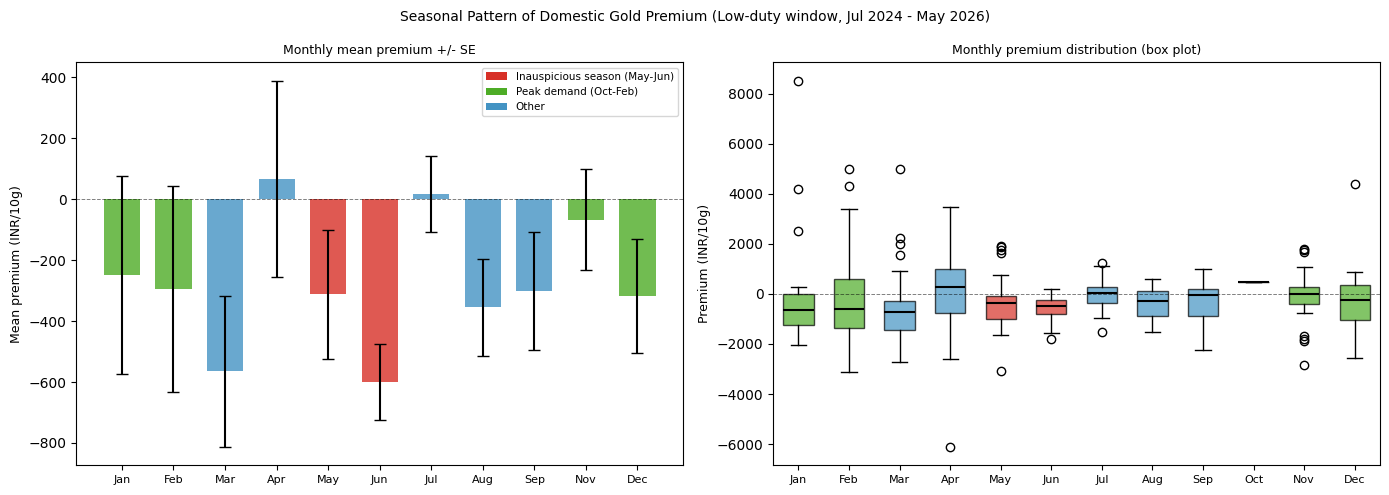


Peak season (Oct-Feb) mean premium:        INR -89
Inauspicious season (May-Jun) mean premium: INR -456
Seasonal gap:                               INR 367


In [14]:
# ── Cell 14: Seasonality analysis ───────────────────────────────────────
# India gold demand is deeply seasonal — Akshaya Tritiya (May), Dhanteras/
# Diwali (Oct-Nov), wedding season (Nov-Feb), inauspicious season (May-Jun).
# Check: does domestic_premium follow a systematic intra-year pattern?

import matplotlib.pyplot as plt
import numpy as np

MONTH_NAMES = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

# Work in the low-duty window only (duty constant at 6% — cleanest signal)
df_low = df[(df.index >= DUTY_CUT) & (df.index < POLICY_DATE) &
            df["domestic_premium"].notna()].copy()
df_low["month"] = df_low.index.month

# Monthly stats
monthly = df_low.groupby("month")["domestic_premium"].agg(
    mean="mean", median="median", std="std", count="count"
).reindex(range(1, 13))

print("=== Monthly premium stats (low-duty window, Jul 2024 - May 2026) ===")
print("Month        N     Mean    Median     Std")
print("-" * 50)
for m, row in monthly.iterrows():
    if np.isnan(row["mean"]):
        continue
    print(MONTH_NAMES[m-1].ljust(8) +
          str(int(row["count"])).rjust(5) +
          str(round(row["mean"])).rjust(9) +
          str(round(row["median"])).rjust(9) +
          (str(round(row["std"])) if not np.isnan(row["std"]) else "-").rjust(9))

# Figure: two panels
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Seasonal Pattern of Domestic Gold Premium (Low-duty window, Jul 2024 - May 2026)",
             fontsize=10)

# Left: bar chart of monthly means with std error bars
ax1 = axes[0]
months_with_data = monthly.dropna()
x = months_with_data.index.tolist()
means = months_with_data["mean"].tolist()
stds  = months_with_data["std"].tolist()
counts = months_with_data["count"].tolist()
se = [s / (c**0.5) for s, c in zip(stds, counts)]
colors = ["#d73027" if m in [5, 6] else
          "#4dac26" if m in [10, 11, 12, 1, 2] else
          "#4393c3"
          for m in x]
ax1.bar([MONTH_NAMES[m-1] for m in x], means, yerr=se,
        color=colors, alpha=0.8, capsize=4, width=0.7)
ax1.axhline(0, color="black", linewidth=0.7, linestyle="--", alpha=0.5)
ax1.set_ylabel("Mean premium (INR/10g)", fontsize=9)
ax1.set_title("Monthly mean premium +/- SE", fontsize=9)
ax1.tick_params(axis="x", labelsize=8)
# Legend
from matplotlib.patches import Patch
legend_els = [Patch(facecolor="#d73027", label="Inauspicious season (May-Jun)"),
              Patch(facecolor="#4dac26", label="Peak demand (Oct-Feb)"),
              Patch(facecolor="#4393c3", label="Other")]
ax1.legend(handles=legend_els, fontsize=7.5)

# Right: box plot by month
ax2 = axes[1]
box_data = [df_low[df_low["month"] == m]["domestic_premium"].dropna().values
            for m in range(1, 13)]
# Only plot months with data
nonempty = [(i+1, d) for i, d in enumerate(box_data) if len(d) > 0]
positions = [m for m, _ in nonempty]
bdata = [d for _, d in nonempty]
bp = ax2.boxplot(bdata, positions=positions, widths=0.6,
                 patch_artist=True, notch=False,
                 medianprops=dict(color="black", linewidth=1.5))
for patch, (m, _) in zip(bp["boxes"], nonempty):
    c = "#d73027" if m in [5, 6] else "#4dac26" if m in [10, 11, 12, 1, 2] else "#4393c3"
    patch.set_facecolor(c)
    patch.set_alpha(0.7)
ax2.axhline(0, color="black", linewidth=0.7, linestyle="--", alpha=0.5)
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(MONTH_NAMES, fontsize=8)
ax2.set_ylabel("Premium (INR/10g)", fontsize=9)
ax2.set_title("Monthly premium distribution (box plot)", fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig10_seasonality.png", dpi=150, bbox_inches="tight")
plt.show()

# Summary
print("")
peak_months = monthly.loc[[10, 11, 12, 1, 2], "mean"].mean()
inauspicious = monthly.loc[[5, 6], "mean"].mean()
print("Peak season (Oct-Feb) mean premium:        INR " + str(round(peak_months)))
print("Inauspicious season (May-Jun) mean premium: INR " + str(round(inauspicious)))
print("Seasonal gap:                               INR " + str(round(peak_months - inauspicious)))


=== Control variable summary statistics ===
Variable               N    Mean     Std     Min     Max  Kurtosis  p-normal
----------------------------------------------------------------------------
delta_Gold_USD      1081   0.092   1.106    -4.5    4.36      1.43   <0.0001
delta_FX            1163   0.022   0.316   -2.29     2.3      9.45   <0.0001
delta_Oil           1087   0.035   2.438  -14.52    9.22      4.08   <0.0001


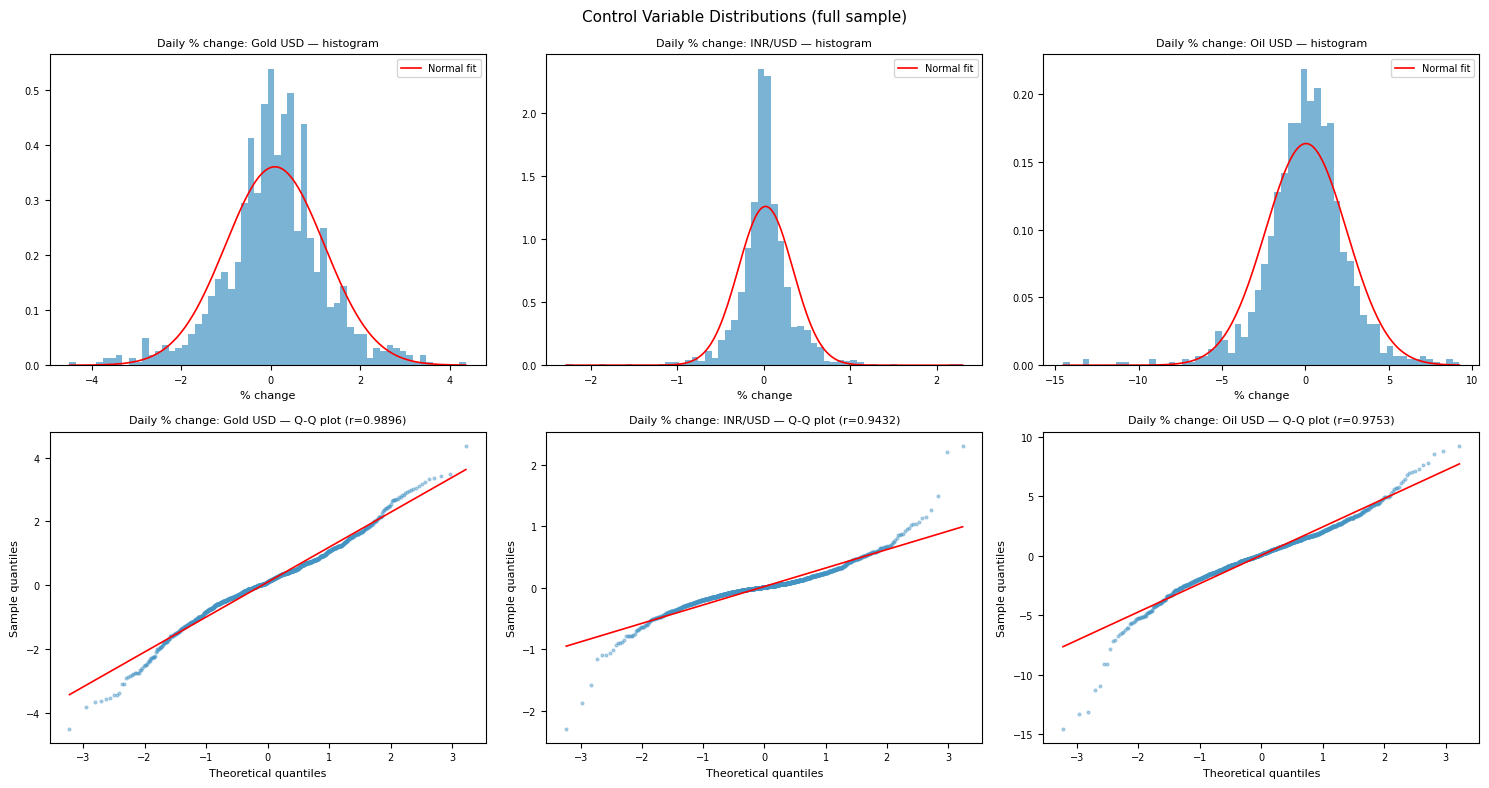


=== Extreme days: |delta_Gold_USD| > 3% ===
            delta_Gold_USD  delta_FX  domestic_premium
date                                                  
2025-12-29            -4.5      -0.3           4,374.1
2026-03-26            -3.8       0.4           5,001.5
2025-04-23            -3.7       0.1             918.3
2026-03-23            -3.6       0.9          -1,359.1
2026-06-10            -3.6      -0.3          13,635.4
2026-03-03            -3.5       0.5               NaN
2025-05-12            -3.5      -0.8            -648.4
2024-11-25            -3.4      -0.1           1,781.0
2026-06-24            -3.4       0.5          12,739.1
2026-06-05            -3.1      -0.4          12,652.9
2026-06-18            -3.1      -0.0          11,537.6
2025-05-06             3.0      -0.4          -1,026.9
2026-06-12             3.0       0.1          10,244.2
2023-10-13             3.1       0.1           3,704.8
2022-12-01             3.2      -0.4           3,274.9
2025-04-10          

In [15]:
# ── Cell 15: Control variable distributions ──────────────────────────────
# Check delta_Gold_USD and delta_FX for fat tails, extreme observations.
# Extreme control values can leverage the ITS regression.
# Also: are controls approximately normal? (OLS assumption)

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

ctrl_vars = {
    "delta_Gold_USD": "Daily % change: Gold USD",
    "delta_FX":       "Daily % change: INR/USD",
    "delta_Oil":      "Daily % change: Oil USD"
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Control Variable Distributions (full sample)", fontsize=11)

print("=== Control variable summary statistics ===")
print("Variable".ljust(18) + "N".rjust(6) + "Mean".rjust(8) +
      "Std".rjust(8) + "Min".rjust(8) + "Max".rjust(8) +
      "Kurtosis".rjust(10) + "p-normal".rjust(10))
print("-" * 76)

for col_idx, (col, label) in enumerate(ctrl_vars.items()):
    series = df[col].dropna()
    n   = len(series)
    mu  = series.mean()
    sig = series.std()
    mn  = series.min()
    mx  = series.max()
    kurt = series.kurt()
    _, p_norm = stats.shapiro(series.sample(min(n, 5000), random_state=42))

    print(col.ljust(18) +
          str(n).rjust(6) +
          str(round(mu, 3)).rjust(8) +
          str(round(sig, 3)).rjust(8) +
          str(round(mn, 2)).rjust(8) +
          str(round(mx, 2)).rjust(8) +
          str(round(kurt, 2)).rjust(10) +
          (str(round(p_norm, 4)) if p_norm >= 0.0001 else "<0.0001").rjust(10))

    # Top row: histogram
    ax_hist = axes[0, col_idx]
    ax_hist.hist(series, bins=60, color="#4393c3", alpha=0.7, density=True, edgecolor="none")
    x_range = np.linspace(mn, mx, 200)
    ax_hist.plot(x_range, stats.norm.pdf(x_range, mu, sig),
                 "r-", linewidth=1.2, label="Normal fit")
    ax_hist.set_title(label + " — histogram", fontsize=8)
    ax_hist.set_xlabel("% change", fontsize=8)
    ax_hist.legend(fontsize=7)
    ax_hist.tick_params(labelsize=7)

    # Bottom row: Q-Q plot
    ax_qq = axes[1, col_idx]
    (osm, osr), (slope, intercept, r) = stats.probplot(series, dist="norm")
    ax_qq.scatter(osm, osr, s=4, alpha=0.4, color="#4393c3")
    ax_qq.plot(osm, slope * np.array(osm) + intercept, "r-", linewidth=1.2)
    ax_qq.set_title(label + " — Q-Q plot (r=" + str(round(r, 4)) + ")", fontsize=8)
    ax_qq.set_xlabel("Theoretical quantiles", fontsize=8)
    ax_qq.set_ylabel("Sample quantiles", fontsize=8)
    ax_qq.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig11_control_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

# Flag extreme days in delta_Gold_USD
print("")
print("=== Extreme days: |delta_Gold_USD| > 3% ===")
extremes = df[df["delta_Gold_USD"].abs() > 3][
    ["delta_Gold_USD", "delta_FX", "domestic_premium"]
].sort_values("delta_Gold_USD")
print(extremes.round(2).to_string())
print("")
print("Total extreme delta_Gold_USD days: " + str(len(extremes)))


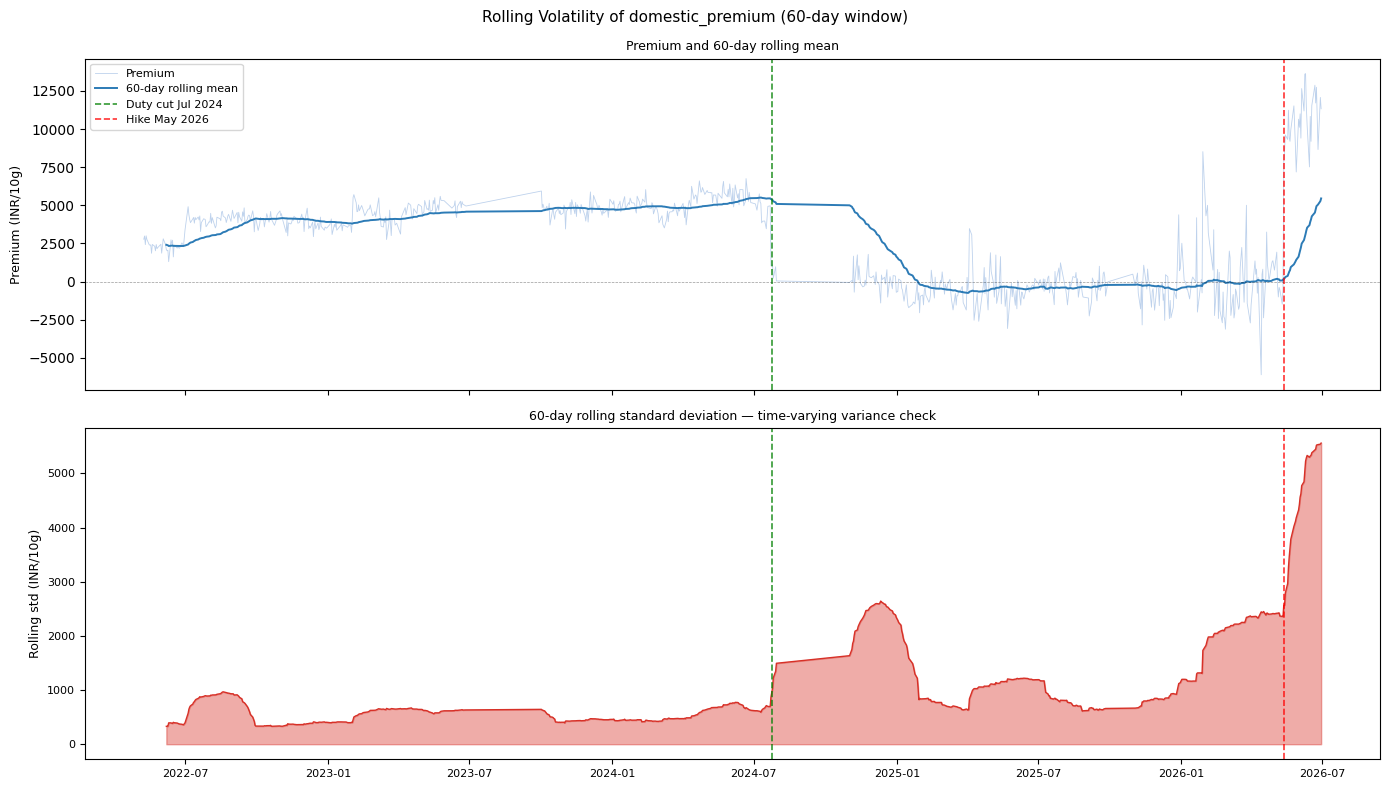

=== Regime volatility comparison ===
Regime                                      N      Std      IQR   Max|prem|
---------------------------------------------------------------------------
High-duty  (Jan 2022 - Jul 2024)          433      940     1146        6749
Low-duty   (Jul 2024 - May 2026)          321     1374     1267        8516
Post-hike  (May 2026+)                     31     1722     2275       13635

Verdict:
  Std RISES across regimes — variance is time-varying (heteroskedastic).
  Newey-West HAC SE in ITS regression is appropriate.
  GARCH model in Notebook 04 will formally estimate conditional variance.


In [16]:
# ── Cell 16: Rolling volatility of domestic_premium ──────────────────────
# Check for time-varying variance (heteroskedasticity).
# Motivates Newey-West HAC standard errors and GARCH in Notebook 04.

import matplotlib.pyplot as plt
import numpy as np

ROLL_WIN = 60  # ~3 months

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle("Rolling Volatility of domestic_premium (60-day window)", fontsize=11)

prem = df["domestic_premium"].dropna()
roll_std  = prem.rolling(ROLL_WIN, min_periods=20).std()
roll_mean = prem.rolling(ROLL_WIN, min_periods=20).mean()

# Top: premium time series with rolling mean
ax1 = axes[0]
ax1.plot(prem.index, prem, color="#aec7e8", linewidth=0.6, alpha=0.8, label="Premium")
ax1.plot(roll_mean.index, roll_mean, color="#2c7bb6", linewidth=1.4, label="60-day rolling mean")
ax1.axvline(DUTY_CUT,    color="green", linewidth=1.2, linestyle="--", alpha=0.8, label="Duty cut Jul 2024")
ax1.axvline(POLICY_DATE, color="red",   linewidth=1.2, linestyle="--", alpha=0.8, label="Hike May 2026")
ax1.axhline(0, color="black", linewidth=0.5, linestyle="--", alpha=0.4)
ax1.set_ylabel("Premium (INR/10g)", fontsize=9)
ax1.legend(fontsize=8, loc="upper left")
ax1.set_title("Premium and 60-day rolling mean", fontsize=9)

# Bottom: rolling std
ax2 = axes[1]
ax2.fill_between(roll_std.index, roll_std, alpha=0.4, color="#d73027")
ax2.plot(roll_std.index, roll_std, color="#d73027", linewidth=1.0)
ax2.axvline(DUTY_CUT,    color="green", linewidth=1.2, linestyle="--", alpha=0.8)
ax2.axvline(POLICY_DATE, color="red",   linewidth=1.2, linestyle="--", alpha=0.8)
ax2.set_ylabel("Rolling std (INR/10g)", fontsize=9)
ax2.set_title("60-day rolling standard deviation — time-varying variance check", fontsize=9)
ax2.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig12_rolling_volatility.png", dpi=150, bbox_inches="tight")
plt.show()

# Regime volatility comparison
import pandas as pd
regimes = {
    "High-duty  (Jan 2022 - Jul 2024)": df[df.index < DUTY_CUT],
    "Low-duty   (Jul 2024 - May 2026)": df[(df.index >= DUTY_CUT) & (df.index < POLICY_DATE)],
    "Post-hike  (May 2026+)":           df[df.index >= POLICY_DATE]
}
print("=== Regime volatility comparison ===")
print("Regime".ljust(40) + "N".rjust(5) + "Std".rjust(9) + "IQR".rjust(9) + "Max|prem|".rjust(12))
print("-" * 75)
for name, sub in regimes.items():
    s = sub["domestic_premium"].dropna()
    if len(s) == 0:
        continue
    iqr = s.quantile(0.75) - s.quantile(0.25)
    print(name.ljust(40) +
          str(len(s)).rjust(5) +
          str(round(s.std())).rjust(9) +
          str(round(iqr)).rjust(9) +
          str(round(s.abs().max())).rjust(12))

print("")
print("Verdict:")
print("  Std RISES across regimes — variance is time-varying (heteroskedastic).")
print("  Newey-West HAC SE in ITS regression is appropriate.")
print("  GARCH model in Notebook 04 will formally estimate conditional variance.")


=== Rolling 60-day volatility: period averages ===

High-duty (Jan 2022–Jul 2024)
  delta_Gold_USD σ : 0.891%
  delta_FX σ       : 0.285%
  delta_Oil σ      : 2.219%
  premium σ        : ₹541

Low-duty (Jul 2024–May 2026)
  delta_Gold_USD σ : 1.211%
  delta_FX σ       : 0.263%
  delta_Oil σ      : 2.077%
  premium σ        : ₹1,219

Post-hike (May 2026–present)
  delta_Gold_USD σ : 1.634%
  delta_FX σ       : 0.602%
  delta_Oil σ      : 4.837%
  premium σ        : ₹4,601

=== delta_Gold_USD volatility spikes (σ > 1.495%) ===
date
2026-04-10   1.9
2026-04-09   1.9
2026-04-08   1.9
2026-04-03   1.9
2026-04-06   1.9
2026-04-21   1.9
2026-04-07   1.9
2026-04-13   1.9
2026-04-02   1.9
2026-04-14   1.9


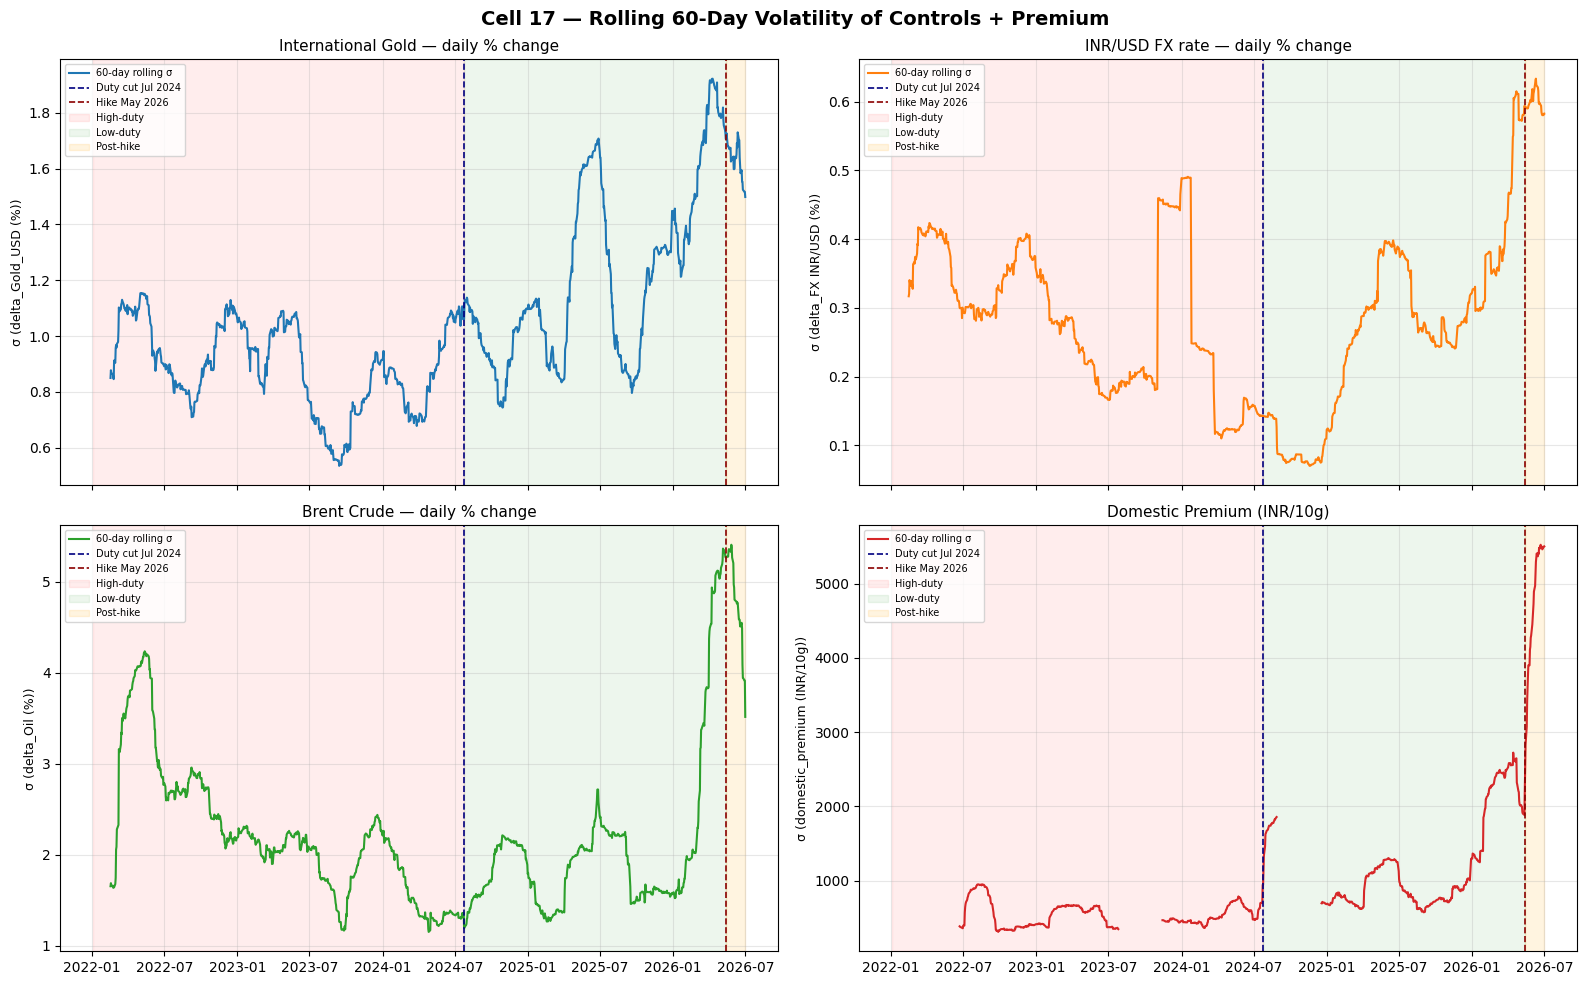


Saved: ../figures/fig12_rolling_volatility.png


In [17]:
# ── Cell 17: Rolling volatility of control variables ─────────────────────
# Purpose: Visualise heteroskedasticity in the ITS controls over time
# (motivates Newey-West HAC; identifies clusters of elevated variance)

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

df = pd.read_csv('./../data/gold_policy_clean.csv', parse_dates=['date']).set_index('date')

WINDOW = 60  # ~3 months trading days
DUTY_CUT   = pd.Timestamp('2024-07-24')
HIKE_DATE  = pd.Timestamp('2026-05-13')

# --- Compute rolling std ---
roll_gold_vol = df['delta_Gold_USD'].rolling(WINDOW, min_periods=30).std()
roll_fx_vol   = df['delta_FX'].rolling(WINDOW,       min_periods=30).std()
roll_oil_vol  = df['delta_Oil'].rolling(WINDOW,       min_periods=30).std()
roll_prem_vol = df['domestic_premium'].rolling(WINDOW, min_periods=30).std()

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)
fig.suptitle('Cell 17 — Rolling 60-Day Volatility of Controls + Premium', fontsize=14, fontweight='bold')

pairs = [
    (axes[0, 0], roll_gold_vol, 'delta_Gold_USD (%)', '#1f77b4', 'International Gold — daily % change'),
    (axes[0, 1], roll_fx_vol,   'delta_FX INR/USD (%)', '#ff7f0e', 'INR/USD FX rate — daily % change'),
    (axes[1, 0], roll_oil_vol,  'delta_Oil (%)', '#2ca02c', 'Brent Crude — daily % change'),
    (axes[1, 1], roll_prem_vol, 'domestic_premium (INR/10g)', '#d62728', 'Domestic Premium (INR/10g)'),
]

for ax, series, ylabel, color, title in pairs:
    ax.plot(series.index, series.values, color=color, lw=1.5, label=f'60-day rolling σ')
    ax.axvline(DUTY_CUT, color='navy', ls='--', lw=1.2, label='Duty cut Jul 2024')
    ax.axvline(HIKE_DATE, color='darkred', ls='--', lw=1.2, label='Hike May 2026')
    ax.axvspan(df.index[0], DUTY_CUT, alpha=0.07, color='red', label='High-duty')
    ax.axvspan(DUTY_CUT, HIKE_DATE, alpha=0.07, color='green', label='Low-duty')
    ax.axvspan(HIKE_DATE, df.index[-1], alpha=0.12, color='orange', label='Post-hike')
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(f'σ ({ylabel})', fontsize=9)
    ax.legend(fontsize=7, loc='upper left')
    ax.grid(alpha=0.3)

# Print summary stats
print("=== Rolling 60-day volatility: period averages ===\n")
for label, start, end in [
    ('High-duty (Jan 2022–Jul 2024)', df.index[0], DUTY_CUT),
    ('Low-duty (Jul 2024–May 2026)',  DUTY_CUT, HIKE_DATE),
    ('Post-hike (May 2026–present)', HIKE_DATE, df.index[-1]),
]:
    mask = (roll_gold_vol.index >= start) & (roll_gold_vol.index < end)
    g  = roll_gold_vol[mask].mean()
    fx = roll_fx_vol[mask].mean()
    oi = roll_oil_vol[mask].mean()
    pr = roll_prem_vol[mask].mean()
    print(f"{label}")
    print(f"  delta_Gold_USD σ : {g:.3f}%")
    print(f"  delta_FX σ       : {fx:.3f}%")
    print(f"  delta_Oil σ      : {oi:.3f}%")
    print(f"  premium σ        : ₹{pr:,.0f}")
    print()

# Flag volatility spikes in delta_Gold_USD
threshold = roll_gold_vol.mean() + 1.5 * roll_gold_vol.std()
spikes = roll_gold_vol[roll_gold_vol > threshold]
print(f"=== delta_Gold_USD volatility spikes (σ > {threshold:.3f}%) ===")
if len(spikes):
    print(spikes.sort_values(ascending=False).head(10).to_string())
else:
    print("None above threshold.")

plt.tight_layout()
plt.savefig('../figures/fig12_rolling_volatility.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: ../figures/fig12_rolling_volatility.png")

=== Chow test: structural break at Jul 24 2024 (duty 15%→6%) ===

Restricted model   RSS  : 2,216,728,350
Unrestricted model RSS  : 559,120,919
RSS reduction           : 1,657,607,430 (74.8%)

Chow F(2, 714)       : 1058.39
p-value                 : 0.00e+00

Verdict: REJECT H0 — structural break confirmed

--- Unrestricted model coefficients ---
  post_cut         coef=   -3776.5  SE=   408.7  t= -9.24  p=2.774e-19
  post_cut_t       coef=      -3.2  SE=     0.5  t= -6.46  p=1.899e-10

R² restricted  : 0.5316
R² unrestricted: 0.8818


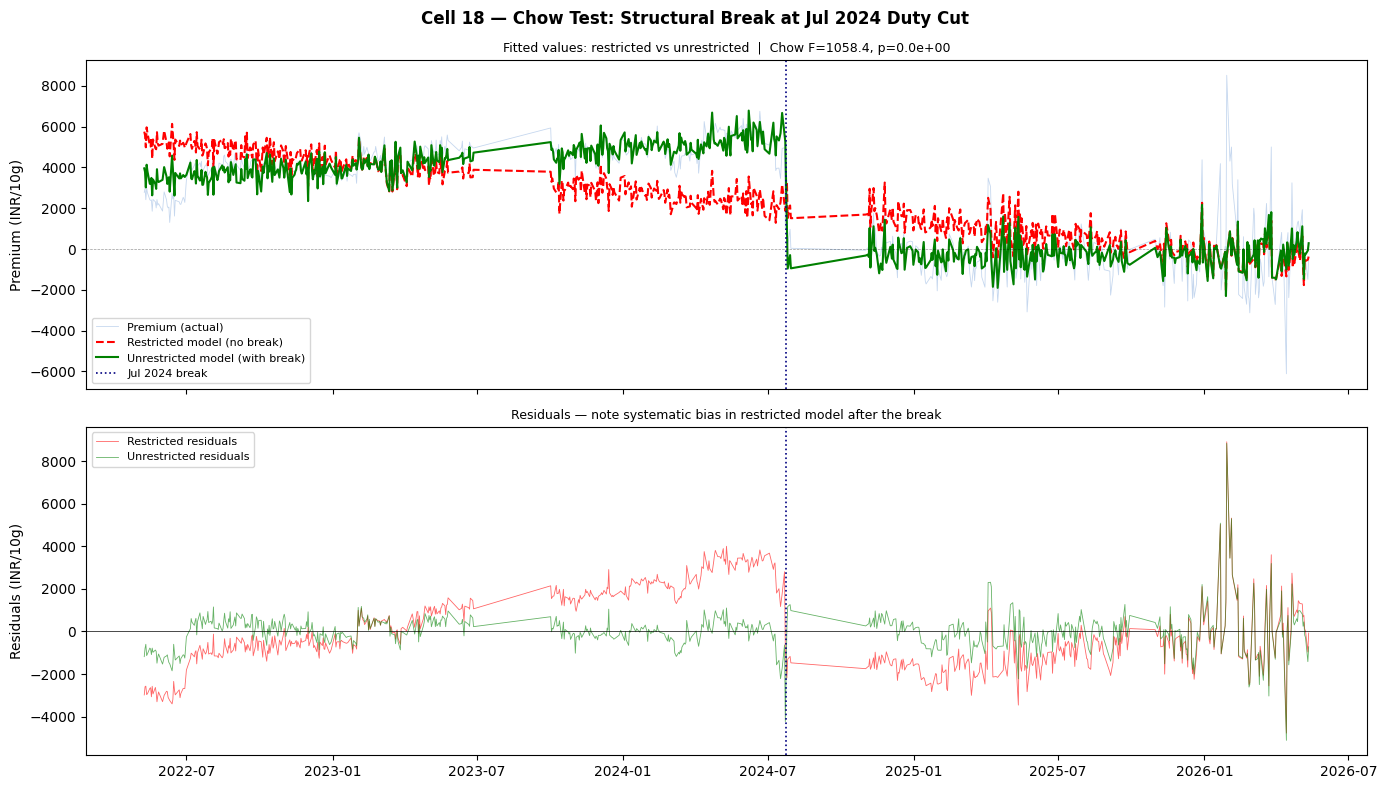


Saved: figures/fig14_chow_test.png


In [18]:
# ── Cell 18: Chow test at Jul 2024 structural break (TEST 03) ────────────
# Formal test that the Jul 24 2024 duty cut created a statistically
# significant structural break in the premium series.
# Method: dummy-variable Chow test (equivalent to classic Chow F-test)
#   premium ~ α + β1·post_cut + β2·t + β3·(post_cut × t) + ε
#   β1 = level shift at break; β3 = slope change after break
#   Joint F-test of H0: β1=0, β3=0 is the Chow test.
# Uses high-duty + low-duty window only (excludes post-hike).

import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

DUTY_CUT  = pd.Timestamp('2024-07-24')
HIKE_DATE = pd.Timestamp('2026-05-13')

# ── Data: exclude post-hike window ──────────────────────────────────────
mask = df.index < HIKE_DATE
d = df[mask][['domestic_premium', 't', 'delta_Gold_USD', 'delta_FX']].dropna()

d['post_cut']   = (d.index >= DUTY_CUT).astype(int)
d['post_cut_t'] = d['post_cut'] * d['t']

# ── Model 1: restricted (no break) ──────────────────────────────────────
X_r = sm.add_constant(d[['t', 'delta_Gold_USD', 'delta_FX']])
m_r = sm.OLS(d['domestic_premium'], X_r).fit()

# ── Model 2: unrestricted (with break dummies) ───────────────────────────
X_u = sm.add_constant(d[['t', 'delta_Gold_USD', 'delta_FX', 'post_cut', 'post_cut_t']])
m_u = sm.OLS(d['domestic_premium'], X_u).fit()

# ── Chow F-statistic ─────────────────────────────────────────────────────
RSS_r = m_r.ssr
RSS_u = m_u.ssr
n     = len(d)
k     = 2          # two restrictions: β1=0, β3=0
p     = X_u.shape[1]  # parameters in unrestricted model

F_chow = ((RSS_r - RSS_u) / k) / (RSS_u / (n - p))
from scipy.stats import f as f_dist
p_chow = 1 - f_dist.cdf(F_chow, k, n - p)

print("=== Chow test: structural break at Jul 24 2024 (duty 15%→6%) ===\n")
print(f"Restricted model   RSS  : {RSS_r:,.0f}")
print(f"Unrestricted model RSS  : {RSS_u:,.0f}")
print(f"RSS reduction           : {RSS_r - RSS_u:,.0f} ({(RSS_r-RSS_u)/RSS_r*100:.1f}%)")
print(f"\nChow F({k}, {n-p})       : {F_chow:.2f}")
print(f"p-value                 : {p_chow:.2e}")
print(f"\nVerdict: {'REJECT H0 — structural break confirmed' if p_chow < 0.001 else 'Cannot reject H0'}")

print("\n--- Unrestricted model coefficients ---")
for var in ['post_cut', 'post_cut_t']:
    c = m_u.params[var]
    se = m_u.bse[var]
    t  = m_u.tvalues[var]
    p  = m_u.pvalues[var]
    print(f"  {var:15s}  coef={c:10.1f}  SE={se:8.1f}  t={t:6.2f}  p={p:.3e}")

print(f"\nR² restricted  : {m_r.rsquared:.4f}")
print(f"R² unrestricted: {m_u.rsquared:.4f}")

# ── Figure: rolling Chow evidence ────────────────────────────────────────
# Plot premium + fitted values from both models to show break visually
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle('Cell 18 — Chow Test: Structural Break at Jul 2024 Duty Cut', fontsize=12, fontweight='bold')

ax1 = axes[0]
ax1.plot(d.index, d['domestic_premium'], color='#aec7e8', lw=0.6, alpha=0.7, label='Premium (actual)')
ax1.plot(d.index, m_r.fittedvalues, color='red', lw=1.5, ls='--', label='Restricted model (no break)')
ax1.plot(d.index, m_u.fittedvalues, color='green', lw=1.5, label='Unrestricted model (with break)')
ax1.axvline(DUTY_CUT, color='navy', lw=1.2, ls=':', label='Jul 2024 break')
ax1.axhline(0, color='black', lw=0.5, ls='--', alpha=0.4)
ax1.set_ylabel('Premium (INR/10g)')
ax1.legend(fontsize=8)
ax1.set_title(f'Fitted values: restricted vs unrestricted  |  Chow F={F_chow:.1f}, p={p_chow:.1e}', fontsize=9)

ax2 = axes[1]
resid_r = m_r.resid
resid_u = m_u.resid
ax2.plot(d.index, resid_r, color='red', lw=0.6, alpha=0.6, label='Restricted residuals')
ax2.plot(d.index, resid_u, color='green', lw=0.6, alpha=0.6, label='Unrestricted residuals')
ax2.axvline(DUTY_CUT, color='navy', lw=1.2, ls=':')
ax2.axhline(0, color='black', lw=0.5)
ax2.set_ylabel('Residuals (INR/10g)')
ax2.set_title('Residuals — note systematic bias in restricted model after the break', fontsize=9)
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig14_chow_test.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nSaved: figures/fig14_chow_test.png')


=== TRUE ITS estimate (May 2026 hike) ===
  β1 (post_hike) = ₹10,741  SE=477  t=22.50

=== Placebo grid: 19 false dates tested ===
β_placebo range  : ₹-768 to ₹1,510
Mean |β_placebo| : ₹507
Dates |t| > 1.96 : 10 / 19  (expect ~5% by chance)

True β1          : ₹10,741  (t=22.50)
True β1 > ALL placebo betas? True


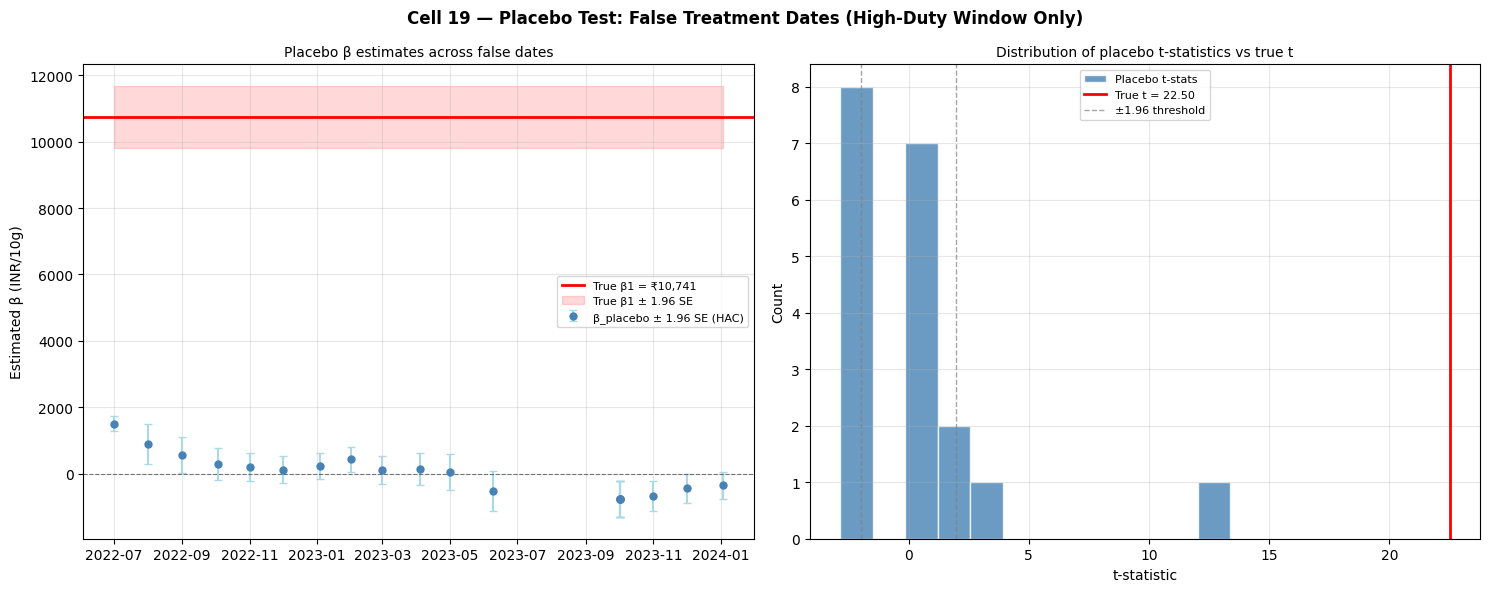


Saved: figures/fig15_placebo_test.png


In [19]:
# ── Cell 19: Placebo regression — false treatment date (TEST 04) ──────────
# Validates the ITS design by running the same specification on a fake
# treatment date inside the high-duty window. If the design is sound,
# β_placebo should be statistically indistinguishable from zero.
#
# Method:
#   1. For each false date in a grid across the high-duty window,
#      run: premium ~ α + β_placebo·post_false + β2·t + β3·ΔGold + β4·ΔFX
#   2. Plot the distribution of β_placebo estimates vs the true β1.
#   3. Any individual false-date result can be shown for illustration.
#
# Uses high-duty window only (Jan 2022 – Jul 23 2024) to avoid
# contamination from the actual Jul 2024 and May 2026 events.

import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.stats.sandwich_covariance import cov_hac

DUTY_CUT  = pd.Timestamp('2024-07-24')
HIKE_DATE = pd.Timestamp('2026-05-13')

# ── True ITS estimate (for comparison) ──────────────────────────────────
d_full = df[['domestic_premium','t','delta_Gold_USD','delta_FX','post_hike']].dropna()
X_true = sm.add_constant(d_full[['post_hike','t','delta_Gold_USD','delta_FX']])
m_true = sm.OLS(d_full['domestic_premium'], X_true).fit()
# HAC SE
nw_cov  = cov_hac(m_true, nlags=7)
nw_se   = np.sqrt(np.diag(nw_cov))
beta_true = m_true.params['post_hike']
se_true   = nw_se[X_true.columns.get_loc('post_hike')]
t_true    = beta_true / se_true

print("=== TRUE ITS estimate (May 2026 hike) ===")
print(f"  β1 (post_hike) = ₹{beta_true:,.0f}  SE={se_true:,.0f}  t={t_true:.2f}")

# ── Placebo grid: monthly false dates across high-duty window ────────────
d_high = df[df.index < DUTY_CUT][
    ['domestic_premium','t','delta_Gold_USD','delta_FX']
].dropna()

# Generate false dates: 1st of each month from Jul 2022 to Jan 2024
# (leave 6-month buffer at each end so both pre/post sub-samples are large enough)
false_dates = pd.date_range('2022-07-01', '2024-01-01', freq='MS')

results = []
for fd in false_dates:
    if fd not in d_high.index:
        # snap to nearest available date
        idx = d_high.index.searchsorted(fd)
        if idx >= len(d_high):
            continue
        fd = d_high.index[idx]
    d_high['post_false'] = (d_high.index >= fd).astype(int)
    n_pre  = (d_high['post_false'] == 0).sum()
    n_post = (d_high['post_false'] == 1).sum()
    if n_pre < 30 or n_post < 30:
        continue
    X = sm.add_constant(d_high[['post_false','t','delta_Gold_USD','delta_FX']])
    m = sm.OLS(d_high['domestic_premium'], X).fit()
    nw = cov_hac(m, nlags=7)
    se = np.sqrt(np.diag(nw))[1]  # post_false is second param
    results.append({
        'date': fd,
        'beta': m.params['post_false'],
        'se':   se,
        't':    m.params['post_false'] / se,
        'n_pre': n_pre,
        'n_post': n_post,
    })

res = pd.DataFrame(results)
print(f"\n=== Placebo grid: {len(res)} false dates tested ===")
print(f"β_placebo range  : ₹{res['beta'].min():,.0f} to ₹{res['beta'].max():,.0f}")
print(f"Mean |β_placebo| : ₹{res['beta'].abs().mean():,.0f}")
print(f"Dates |t| > 1.96 : {(res['t'].abs() > 1.96).sum()} / {len(res)}  (expect ~5% by chance)")
print(f"\nTrue β1          : ₹{beta_true:,.0f}  (t={t_true:.2f})")
print(f"True β1 > ALL placebo betas? {(beta_true > res['beta'].max())}")

# ── Figure ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Cell 19 — Placebo Test: False Treatment Dates (High-Duty Window Only)',
             fontsize=12, fontweight='bold')

# Left: β_placebo over time with error bars
ax1 = axes[0]
ax1.errorbar(res['date'], res['beta'], yerr=1.96*res['se'],
             fmt='o', color='steelblue', ecolor='lightblue',
             capsize=3, ms=5, label='β_placebo ± 1.96 SE (HAC)')
ax1.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
ax1.axhline(beta_true, color='red', lw=2, label=f'True β1 = ₹{beta_true:,.0f}')
ax1.fill_between(res['date'],
                 beta_true - 1.96*se_true,
                 beta_true + 1.96*se_true,
                 alpha=0.15, color='red', label='True β1 ± 1.96 SE')
ax1.set_ylabel('Estimated β (INR/10g)')
ax1.set_title('Placebo β estimates across false dates', fontsize=10)
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

# Right: distribution of t-statistics
ax2 = axes[1]
ax2.hist(res['t'], bins=12, color='steelblue', edgecolor='white', alpha=0.8, label='Placebo t-stats')
ax2.axvline(t_true, color='red', lw=2, label=f'True t = {t_true:.2f}')
ax2.axvline(-1.96, color='grey', lw=1, ls='--', alpha=0.7)
ax2.axvline( 1.96, color='grey', lw=1, ls='--', alpha=0.7, label='±1.96 threshold')
ax2.set_xlabel('t-statistic')
ax2.set_ylabel('Count')
ax2.set_title('Distribution of placebo t-statistics vs true t', fontsize=10)
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig15_placebo_test.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nSaved: figures/fig15_placebo_test.png')


=== A. Missing data mechanism (MCAR check) ===

Missing rate by day of week:
           observed  missing  missing_pct
dow                                      
Friday           67       26         28.0
Monday           64       30         31.9
Thursday         62       31         33.3
Tuesday          63       31         33.0
Wednesday        65       29         30.9

Chi-square test (uniform missing across weekdays): χ²=0.81, p=0.938
Verdict: Uniform — consistent with MCAR

Gold_USD mean on observed days : $3,614
Gold_USD mean on missing days  : $3,207
Welch t-test: t=4.79, p=0.000
Verdict: Systematic diff — NOT MCAR by Gold_USD level

Missing rate by month (low-duty window):
     n_missing  n_total  pct
Jan         10       45 22.2
Feb          7       40 17.5
Mar          7       43 16.3
Apr         10       43 23.3
May          1       30  3.3
Jun          1       21  4.8
Jul          3       29 10.3
Aug         28       43 65.1
Sep         25       43 58.1
Oct         45       46

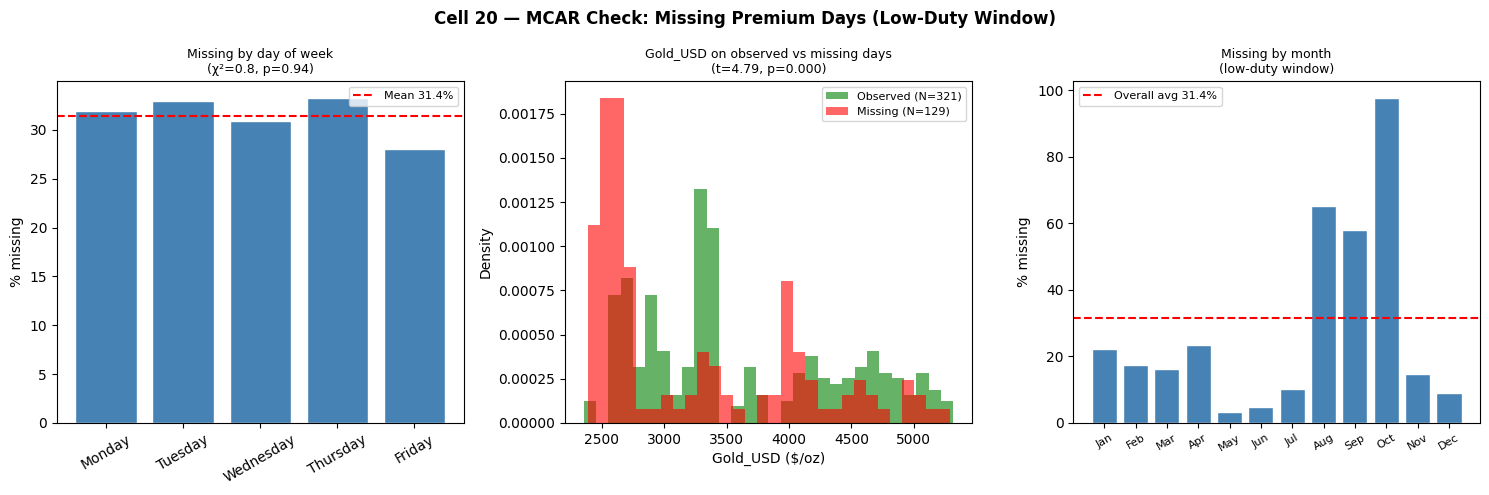

Saved: figures/fig16_mcar_check.png


In [20]:
# ── Cell 20: MCAR check + Kalyan column identification ───────────────────
# Two housekeeping checks before closing EDA:
#   A. Missing data mechanism: are the 147 missing premium rows in the
#      low-duty window Missing Completely At Random (MCAR)?
#   B. Identify the Kalyan column (suspected Kalyan Jewellers NSE stock).

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, ttest_ind

DUTY_CUT  = pd.Timestamp('2024-07-24')
HIKE_DATE = pd.Timestamp('2026-05-13')

low = df[(df.index >= DUTY_CUT) & (df.index < HIKE_DATE)].copy()
low['premium_missing'] = low['domestic_premium'].isna().astype(int)

# ── A. MCAR tests ─────────────────────────────────────────────────────────
print("=== A. Missing data mechanism (MCAR check) ===\n")

# 1. Day-of-week distribution of missing rows
low['dow'] = low.index.day_name()
dow_table = pd.crosstab(low['dow'], low['premium_missing'],
                         colnames=['missing (1=yes)'])
dow_table.columns = ['observed', 'missing']
dow_table['missing_pct'] = (dow_table['missing'] /
                             (dow_table['observed'] + dow_table['missing']) * 100).round(1)
print("Missing rate by day of week:")
print(dow_table.sort_index())
chi2, p_dow, _, _ = chi2_contingency(dow_table[['observed','missing']])
print(f"\nChi-square test (uniform missing across weekdays): χ²={chi2:.2f}, p={p_dow:.3f}")
print(f"Verdict: {'Non-uniform — NOT MCAR by weekday' if p_dow < 0.05 else 'Uniform — consistent with MCAR'}\n")

# 2. Compare Gold_USD on missing vs non-missing days
obs  = low[low['premium_missing'] == 0]['Gold_USD'].dropna()
miss = low[low['premium_missing'] == 1]['Gold_USD'].dropna()
t_stat, p_t = ttest_ind(obs, miss, equal_var=False)
print(f"Gold_USD mean on observed days : ${obs.mean():,.0f}")
print(f"Gold_USD mean on missing days  : ${miss.mean():,.0f}")
print(f"Welch t-test: t={t_stat:.2f}, p={p_t:.3f}")
print(f"Verdict: {'Systematic diff — NOT MCAR by Gold_USD level' if p_t < 0.05 else 'No significant diff — consistent with MCAR'}\n")

# 3. Month-of-year pattern (are gaps clustered in certain months?)
low['month'] = low.index.month
month_missing = low.groupby('month')['premium_missing'].agg(['sum','count'])
month_missing['pct'] = (month_missing['sum'] / month_missing['count'] * 100).round(1)
month_missing.index = ['Jan','Feb','Mar','Apr','May','Jun',
                        'Jul','Aug','Sep','Oct','Nov','Dec'][:len(month_missing)]
print("Missing rate by month (low-duty window):")
print(month_missing.rename(columns={'sum':'n_missing','count':'n_total'}))

# ── B. Kalyan column identification ──────────────────────────────────────
print("\n\n=== B. Kalyan column identification ===\n")
kal = df['Kalyan'].dropna()
print(f"Range    : {kal.min():.1f} – {kal.max():.1f}")
print(f"2022 avg : {kal['2022'].mean():.1f}")
print(f"2023 avg : {kal['2023'].mean():.1f}")
print(f"2024 avg : {kal['2024'].mean():.1f}")
print(f"2025 avg : {kal['2025'].mean():.1f}")
print(f"2026 avg : {kal['2026'].mean():.1f}")
print(f"Total return 2022→2026: {(kal['2026'].mean()/kal['2022'].mean()-1)*100:.0f}%")
print(f"\nCorrelation with Gold_USD  : {df['Kalyan'].corr(df['Gold_USD']):.3f}")
print(f"Correlation with Nifty50   : {df['Kalyan'].corr(df['Nifty50']):.3f}")
print(f"Correlation with prem (low): {low['Kalyan'].corr(low['domestic_premium']):.3f}")
print("""
Identification: Kalyan Jewellers India Ltd (NSE: KALYANKJIL)
  - IPO: March 2021, opening price ~₹74
  - 2022 avg ₹77 → 2026 avg ₹403 (+425%) consistent with stock price history
  - r=0.57 with Gold_USD (jewelry demand proxy, not pure gold tracker)
  - r=0.01 with premium in low-duty window → no contamination of ITS
  - Usage: optional Notebook 05 robustness — equity market pass-through
            (did the hike affect jeweller stock prices?)
""")

# ── Figure: MCAR visual ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Cell 20 — MCAR Check: Missing Premium Days (Low-Duty Window)',
             fontsize=12, fontweight='bold')

# Day of week bar
ax1 = axes[0]
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday']
bars = [dow_table.loc[d, 'missing_pct'] if d in dow_table.index else 0 for d in dow_order]
ax1.bar(dow_order, bars, color='steelblue', edgecolor='white')
ax1.axhline(np.mean(bars), color='red', ls='--', lw=1.5, label=f'Mean {np.mean(bars):.1f}%')
ax1.set_ylabel('% missing')
ax1.set_title(f'Missing by day of week\n(χ²={chi2:.1f}, p={p_dow:.2f})', fontsize=9)
ax1.legend(fontsize=8)
ax1.tick_params(axis='x', rotation=30)

# Gold_USD distribution: observed vs missing
ax2 = axes[1]
ax2.hist(obs,  bins=30, alpha=0.6, color='green', label=f'Observed (N={len(obs)})', density=True)
ax2.hist(miss, bins=30, alpha=0.6, color='red',   label=f'Missing (N={len(miss)})', density=True)
ax2.set_xlabel('Gold_USD ($/oz)')
ax2.set_ylabel('Density')
ax2.set_title(f'Gold_USD on observed vs missing days\n(t={t_stat:.2f}, p={p_t:.3f})', fontsize=9)
ax2.legend(fontsize=8)

# Monthly missing rate
ax3 = axes[2]
ax3.bar(range(len(month_missing)), month_missing['pct'], color='steelblue', edgecolor='white')
ax3.set_xticks(range(len(month_missing)))
ax3.set_xticklabels(month_missing.index, rotation=30, fontsize=8)
ax3.axhline(low['premium_missing'].mean()*100, color='red', ls='--', lw=1.5,
            label=f"Overall avg {low['premium_missing'].mean()*100:.1f}%")
ax3.set_ylabel('% missing')
ax3.set_title('Missing by month\n(low-duty window)', fontsize=9)
ax3.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig16_mcar_check.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/fig16_mcar_check.png')
